<a href="https://colab.research.google.com/github/carlosmvond/hybrid-modelling-of-batch-bioreactors/blob/main/sweep_case_study_2_yeast_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The first code serves to plot the data from the article:

Liu, Y. S., & Wu, J. Y. (2008). Modeling of Xanthophyllomyces dendrorhous growth on glucose and overflow metabolism in batch and fed‐batch cultures for astaxanthin production. Biotechnology and bioengineering, 101(5), 996-1004.

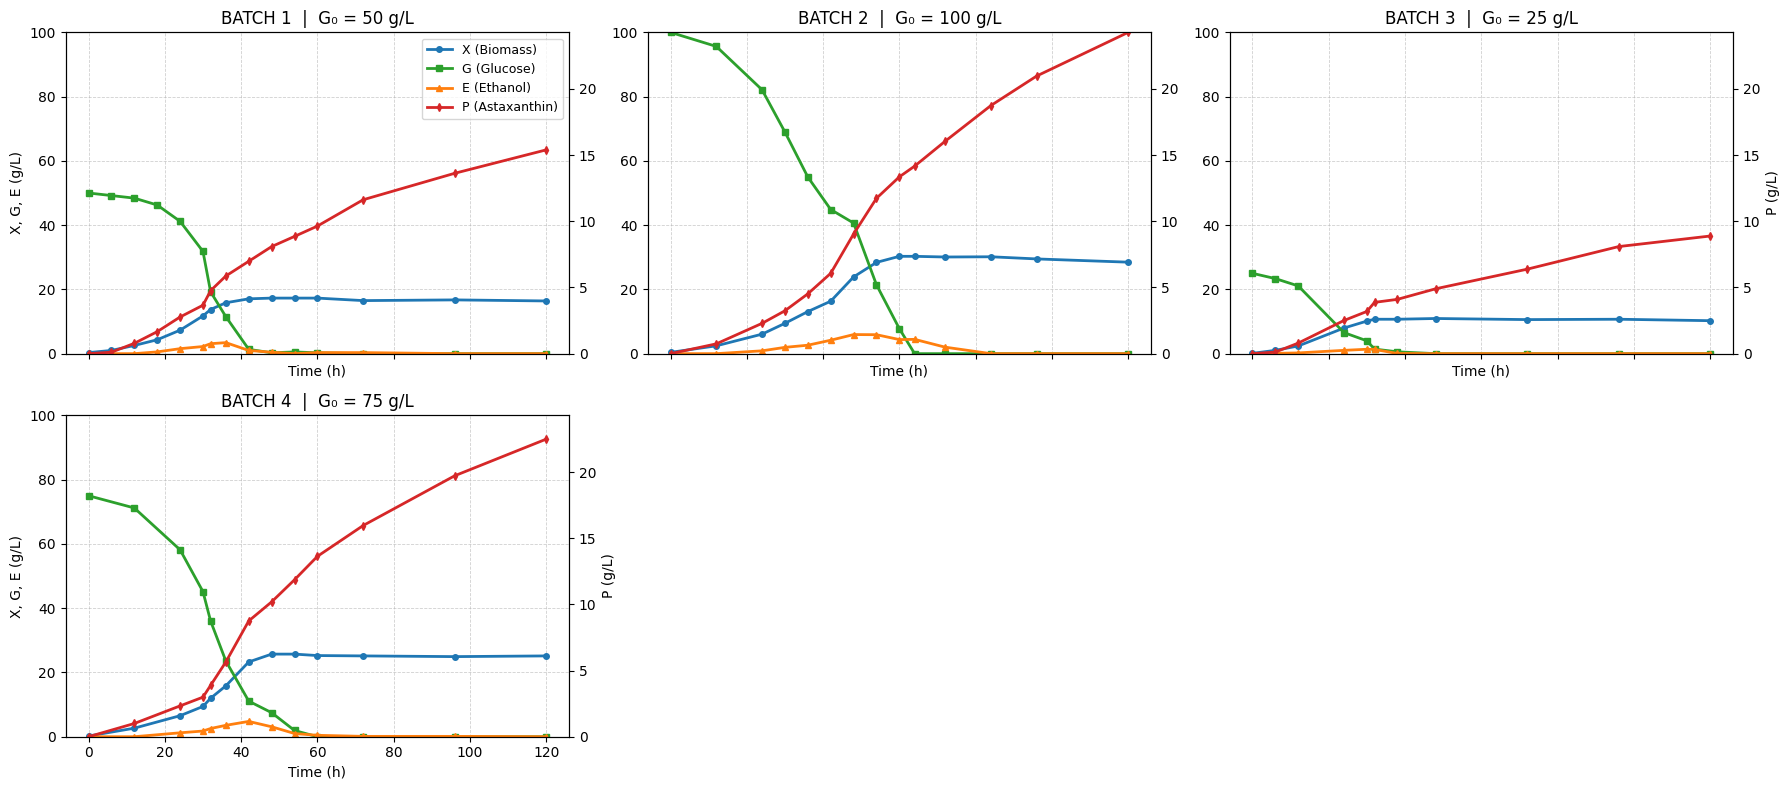

In [1]:
import matplotlib.pyplot as plt
import numpy as np


# === Experimental data ===
raw_t = [
    [0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 32.0, 36.0, 42.0, 48.0, 54.0, 60.0, 72.0, 96.0, 120.0],
    [0.0, 12.0, 24.0, 30.0, 36.0, 42.0, 48.0, 54.0, 60.0, 64.0, 72.0, 84.0, 96.0, 120.0],
    [0.0, 6.0, 12.0, 24.0, 30.0, 32.0, 38.0, 48.0, 72.0, 96.0, 120.0],
    [0.0, 12.0, 24.0, 30.0, 32.0, 36.0, 42.0, 48.0, 54.0, 60.0, 72.0, 96.0, 120.0]
]
raw_X = [
    [0.33, 1.00, 2.55, 4.32, 7.31, 11.75, 13.74, 15.84, 17.06, 17.29, 17.29, 17.29, 16.51, 16.73, 16.40],
    [0.40, 2.43, 6.07, 9.44, 13.09, 16.32, 23.88, 28.40, 30.29, 30.29, 30.08, 30.15, 29.48, 28.47],
    [0.10, 1.03, 2.39, 7.98, 10.14, 10.71, 10.71, 10.94, 10.60, 10.71, 10.26],
    [0.22, 2.66, 6.54, 9.42, 11.97, 15.84, 23.27, 25.71, 25.71, 25.26, 25.15, 24.93, 25.15]
]
raw_G = [
    [50.00, 49.20, 48.40, 46.26, 41.18, 31.82, 19.25, 11.50, 1.34, 0.27, 0.53, 0.27, 0.00, 0.00, 0.00],
    [100.00, 95.62, 82.12, 68.97, 54.97, 44.86, 40.64, 21.42, 7.76, 0.00, 0.00, 0.00, 0.00, 0.00],
    [25.00, 23.36, 21.08, 6.55, 3.99, 1.42, 0.57, 0.00, 0.00, 0.00, 0.00],
    [75.00, 71.19, 58.17, 45.15, 36.01, 23.55, 11.08, 7.48, 1.94, 0.00, 0.00, 0.00, 0.00]
]
raw_E = [
    [0.00, 0.00, 0.00, 0.55, 1.55, 2.22, 3.10, 3.43, 1.00, 0.44, 0.00, 0.33, 0.33, 0.00, 0.00],
    [0.00, 0.00, 0.88, 1.96, 2.63, 4.18, 5.94, 5.90, 4.38, 4.45, 2.02, 0.00, 0.00, 0.00],
    [0.00, 0.10, 0.23, 1.03, 1.37, 1.32, 0.05, 0.00, 0.00, 0.00, 0.00],
    [0.00, 0.00, 1.22, 1.77, 2.55, 3.55, 4.76, 3.10, 1.00, 0.44, 0.11, 0.11, 0.00]
]
raw_P = [
    [0.00, 0.11, 0.78, 1.66, 2.77, 3.66, 4.76, 5.87, 6.98, 8.09, 8.86, 9.64, 11.63, 13.63, 15.40],
    [0.00, 0.74, 2.29, 3.24, 4.52, 6.07, 9.04, 11.74, 13.36, 14.17, 16.05, 18.75, 20.98, 24.28],
    [0.000, 0.120, 0.798, 2.507, 3.191, 3.875, 4.103, 4.900, 6.382, 8.091, 8.889],
    [0.00, 1.00, 2.33, 2.99, 3.88, 5.65, 8.75, 10.19, 11.86, 13.63, 15.96, 19.72, 22.49]
]

# Infer S0 as the first glucose value (G) of each batch
initial_substrates = [float(np.array(G)[0]) for G in raw_G]

# --- Consistent colors across all plots ---
COL_X = "#1f77b4"  # blue
COL_G = "#2ca02c"  # green
COL_E = "#ff7f0e"  # orange
COL_P = "#d62728"  # red (right axis)

# --- Global min/max values to ensure consistent axis limits ---
X_all = np.concatenate([np.asarray(X, dtype=float) for X in raw_X])
G_all = np.concatenate([np.asarray(G, dtype=float) for G in raw_G])
E_all = np.concatenate([np.asarray(E, dtype=float) for E in raw_E])
P_all = np.concatenate([np.asarray(P, dtype=float) for P in raw_P])

ymin_left  = min(X_all.min(), G_all.min(), E_all.min())
ymax_left  = max(X_all.max(), G_all.max(), E_all.max())
ymin_right = P_all.min()
ymax_right = P_all.max()

# --- Figure layout: 2 rows × 3 columns ---
n_batches = len(initial_substrates)
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
axes = axes.flatten()

for i, (S0, t_i, X_i, G_i, E_i, P_i) in enumerate(
    zip(initial_substrates, raw_t, raw_X, raw_G, raw_E, raw_P)
):
    ax1 = axes[i]
    ax2 = ax1.twinx()

    t = np.asarray(t_i, dtype=float)
    X = np.asarray(X_i, dtype=float)
    G = np.asarray(G_i, dtype=float)
    E = np.asarray(E_i, dtype=float)
    P = np.asarray(P_i, dtype=float)

    # --- Left axis: X, G, and E (lines + markers) ---
    ax1.plot(t, X, '-o', lw=2, ms=4, color=COL_X, label='X (Biomass)')
    ax1.plot(t, G, '-s', lw=2, ms=4, color=COL_G, label='G (Glucose)')
    ax1.plot(t, E, '-^', lw=2, ms=4, color=COL_E, label='E (Ethanol)')
    ax1.set_ylim(ymin_left, ymax_left)
    ax1.set_xlabel("Time (h)")
    if i % 3 == 0:
        ax1.set_ylabel("X, G, E (g/L)")

    # --- Right axis: P (Astaxanthin) ---
    ax2.plot(t, P, '-d', lw=2, ms=4, color=COL_P, label='P (Astaxanthin)')
    ax2.set_ylim(ymin_right, ymax_right)
    if i % 3 == 2 or i == n_batches - 1:
        ax2.set_ylabel("P (g/L)")

    # --- Title with batch number and initial substrate ---
    ax1.set_title(f"BATCH {i+1}  |  G₀ = {S0:g} g/L")

    # --- Grid styling ---
    ax1.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)

    # --- Combined legend (only for the first subplot) ---
    if i == 0:
        l1, lab1 = ax1.get_legend_handles_labels()
        l2, lab2 = ax2.get_legend_handles_labels()
        ax1.legend(l1 + l2, lab1 + lab2, loc="upper right", fontsize=9)

# --- Turn off unused subplots if there are fewer than 6 batches ---
for j in range(n_batches, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import numpy as np

def plot_network(net_params, layer_sizes, title="Neural Network (weight magnitudes)"):
    """
    Draws a simple feedforward network diagram where connection transparency
    indicates the absolute value of the weight.
    """
    # Normalize all weights to [0,1] for visualization
    all_weights = np.concatenate([np.abs(np.ravel(np.array(net_params[k])))
                                  for k in net_params if k.startswith("W")])
    w_max = np.max(all_weights) if np.max(all_weights) > 0 else 1.0

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.axis("off")

    # Horizontal spacing between layers
    x_spacing = 2.0
    y_spacing = 1.0

    # Find max layer width for vertical centering
    max_neurons = max(layer_sizes)

    # Compute coordinates for each layer
    coords = []
    for i, n in enumerate(layer_sizes):
        y_positions = np.linspace(-y_spacing*(n-1)/2, y_spacing*(n-1)/2, n)
        x_positions = np.full(n, i * x_spacing)
        coords.append(list(zip(x_positions, y_positions)))

    # Plot connections
    for i in range(len(layer_sizes)-1):
        W = np.array(net_params[f"W{i}"])
        for n_out, (x2, y2) in enumerate(coords[i+1]):
            for n_in, (x1, y1) in enumerate(coords[i]):
                w = W[n_out, n_in]
                alpha = min(1.0, abs(w)/w_max)   # normalize transparency
                color = 'blue' if w >= 0 else 'red'
                ax.plot([x1, x2], [y1, y2], color=color, alpha=alpha, lw=1.2)

    # Plot neurons as circles
    for layer in coords:
        for (x, y) in layer:
            ax.scatter(x, y, s=120, color="black", zorder=3)

    ax.set_title(title)
    plt.tight_layout()
    plt.show()


The following code trains two competing hybrid models on the astaxanthin data and
compares them under identical conditions. For every combination of hyperparameters and
every random seed, both models are trained back to back with the same optimizer, solver,
data partition, minibatch strategy, dropout rate and seed, so that the only thing that
differs between them is the structure imposed a priori.

**M1 — proposed framework** (no reaction scheme assumed)

$$
\begin{aligned}
\frac{dX}{dt} &= f_{1}(\cdot)\,X,\\[4pt]
\frac{dG}{dt} &= f_{2}(\cdot)\,G\,X,\\[4pt]
\frac{dE}{dt} &= f_{3}(\cdot)\,E\,X + g_{3}(\cdot)\,X,\\[4pt]
\frac{dP}{dt} &= f_{4}(\cdot)\,P + g_{4}(\cdot)\,X.
\end{aligned}
$$

The functions $f_1,\dots,f_4$, $g_3$ and $g_4$ form the **output layer** of the neural
network, which receives $(X,G,E,P)$ as input. The output activation is the **identity**
for the $f_i$, which must be free to take negative values, and **ReLU** for $g_3$ and
$g_4$, which enforces non-negativity of the generation terms. No mechanistic parameter
is introduced.

**M2 — hybridized Liu & Wu (2008)** (mass balances with a postulated reaction scheme)

$$
\begin{aligned}
\frac{dX}{dt} &= (r_G + r_E - k_d)\,X,\\[4pt]
\frac{dG}{dt} &= -\left(\frac{r_G}{Y_{X/G}}+\frac{r_F}{Y_{E/G}}\right)X,\\[4pt]
\frac{dE}{dt} &= \left(r_F-\frac{r_E}{Y_{X/E}}\right)X,\\[4pt]
\frac{dP}{dt} &= \alpha\,\frac{dX}{dt}+\beta X .
\end{aligned}
$$

Here the network outputs are the three reaction rates $r_G, r_E, r_F$, all passed
through a ReLU. The yields $Y_{X/G}$ and $Y_{X/E}$ are measured directly from the
training batches at start-up, $Y_{E/G}=0.511$ is stoichiometric and never fitted, and
$k_d$, $\alpha$ and $\beta$ are estimated jointly with the network weights.

---

### 🔧 Algorithm configuration

The algorithm is configured at the beginning of the code. Rather than a single setting
per option, the script sweeps a grid: every combination in the grid is trained with
`N_SEEDS` random initializations, and for each model the configuration attaining the
lowest validation loss is reported.

- **MODELS:** which models to train, `["M1", "M2"]`. Each writes its own csv and its own
  Excel workbook.

- **TRAIN_MODE** (`"batch"` | `"global"`):
  - `"batch"`: each batch experiment is treated as an independent minibatch; parameters
    are updated once per experiment, so several times per epoch.
  - `"global"`: the loss of all experiments is accumulated and a single update is
    performed per epoch (full-batch optimization).

- **GRID_LR:** learning rates swept for the Adam optimizer. High values may destabilize
  training; low values may slow convergence.

- **GRID_DROPOUT:** dropout rates swept. A fraction of hidden neurons is randomly
  deactivated at each update. The rate is never zero, since the predictive intervals are
  obtained by keeping dropout active at prediction time.

- **GRID_ACTIVATION:** hidden-layer activation, `tanh` or `relu`. Only the hidden
  activation is swept; the output activations are structural, not tunable.

- **GRID_HIDDEN:** architectures swept, given as lists of hidden-layer widths.

- **GRID_LAMBDA_IC:** weight of the penalty on the estimated initial conditions. The
  initial values of $X$ and $G$ of each training experiment are adjusted through
  log-offsets, and this term keeps them close to the measured ones.

- **NUM_EPOCHS:** maximum number of complete passes through the training set. Throughout
  training the parameters attaining the lowest validation loss are retained, and those
  define the model reported for the run.

- **SEED_START / N_SEEDS:** first seed and number of random initializations per
  configuration. The resume logic keys on (model, configuration, seed), so `N_SEEDS` can
  be raised later and the sweep re-run: runs already in the csv are skipped.

- **train_idxs / valid_idxs / test_idxs:** the data partition, defined at the experiment
  level.

- **SOLVER, ODE_RTOL, ODE_ATOL, ODE_MAX_STEPS:** ODE integration. The default is the
  Tsit5 explicit Runge–Kutta method of `diffrax` with adaptive step size; gradients are
  obtained by backpropagating through the solver.

- **CALIB_STEPS / CALIB_LR:** zero-field pretraining. Before training, the network
  outputs are driven to zero so that the initial vector field nearly vanishes and the
  states stay at their initial conditions, giving a neutral starting point.

- **DIVERGENCE_THRESHOLD:** a run whose loss grows beyond this value, or which exceeds
  the bound on internal solver steps, is aborted and flagged as diverged. The retained
  parameters still correspond to the best epoch reached before the interruption.

- **EPS:** small positive constant that stabilizes the divisions in the loss function,
  typically $10^{-8}$.

- **MAX_CONFIGS:** limits the sweep to the first configurations, useful for a smoke test.
  `None` runs the whole grid.

---

### 🧠 MLP architecture

Defined by `GRID_HIDDEN` and assembled into `layer_sizes` as
`input – hidden … – output`. The input dimension is always **4**, the state vector
$(X,G,E,P)$, while the output dimension depends on the model: **6** for M1
($f_1,\dots,f_4,g_3,g_4$) and **3** for M2 ($r_G,r_E,r_F$). A configuration with
`hidden = [7,7,7]` therefore gives `4-7-7-7-6` for M1 and `4-7-7-7-3` for M2. The
start-up banner prints, for every architecture and model, the resulting number of
weights and the ratio of training measurements per weight.

---

### 📦 Outputs

For each model the script writes `sweep_runs_<model>.csv` (one row per run) and
`sensitivity_<model>.xlsx`, whose sheets hold the individual runs, a per-configuration
summary across seeds, the architecture comparison, the dispersion of the fitted
mechanistic parameters, the determination coefficients in long format and the protocol
of the sweep. Trajectory and loss figures are saved per run, the best parameters of
every run are pickled, and vector figures are produced for the best run of each model.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 11.1 MB/s eta 0:00:00
Installing jax, diffrax and optax (first run only)...


/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:90: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


jax 0.11.1 | diffrax 0.7.2 | optax 0.2.8
Backend: tpu | Devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]
Matplotlib backend: module://matplotlib_inline.backend_inline | SHOW_PLOTS=True

Yield coefficients measured on the TRAINING batches
 batch      G0   E_peak      Y_XG      Y_XE
     0    50.0     3.43    0.4029        --
     2    25.0     1.37    0.4779        --
     3    75.0     4.76    0.3606        --
  mean Y_XG = 0.4138   (Liu & Wu report 0.372)
  mean Y_XE = 0.3240   (Liu & Wu report 0.324)
  Y_EG      = 0.5110   (stoichiometric, never fitted)

FULL SWEEP: 1 LR x 1 dropout x 1 arch x 1 lambda x 2 activation = 2 configurations
Models: M1, M2 | seeds: 1 | total trainings: 4
------------------------------------------------------------------------------
Training measurements: 156 (3 experiments x 4 state variables)

  M1 Proposed framework (6 network outputs, 0 fitted mechanistic parameters, 0 fixed coefficients)
          hidden   weights   obs/param

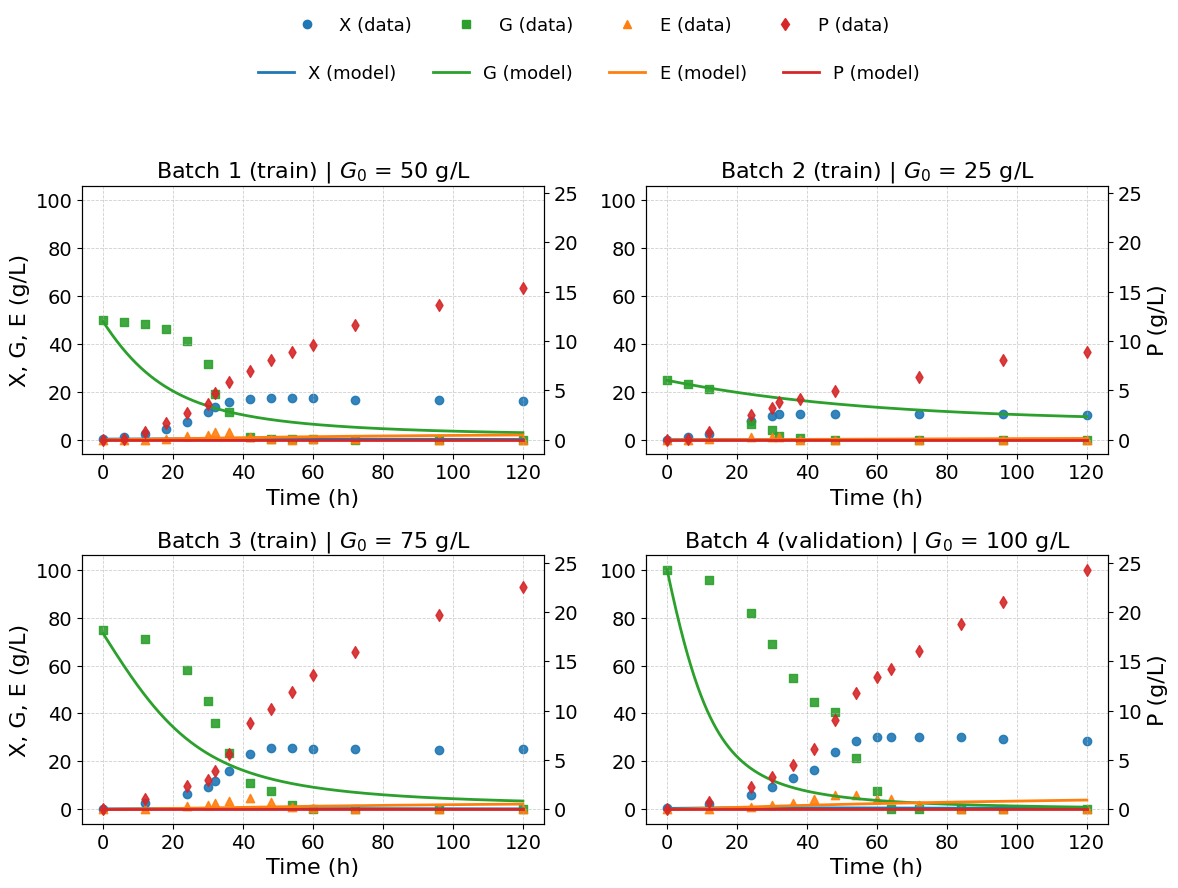

     --> NEW BEST for M1: 4.6970e+00
     M2:
        ep 400: train=7.640020, valid=8.535807
        ep 800: train=7.078764, valid=8.520378
        ep 1200: train=6.751185, valid=8.468910
        ep 1600: train=6.538164, valid=7.772539
        ep 2000: train=4.349448, valid=6.751898
        ep 2400: train=4.041246, valid=6.250063
        ep 2800: train=3.968547, valid=6.710320
        ep 3200: train=4.092272, valid=3.816532
        ep 3600: train=5.345359, valid=8.367042
        ep 4000: train=4.968088, valid=8.370297
        ep 4400: train=4.741893, valid=8.457482
        ep 4800: train=4.520897, valid=8.506692
        ep 5200: train=4.407331, valid=8.533032
        ep 5600: train=4.354003, valid=8.545711
        ep 6000: train=4.330082, valid=8.551115
        ep 6400: train=4.324262, valid=8.554477
        ep 6800: train=4.323067, valid=8.556000
        ep 7200: train=4.322950, valid=8.556357
        ep 7600: train=4.322937, valid=8.556614
        ep 8000: train=4.322928, valid=8.556

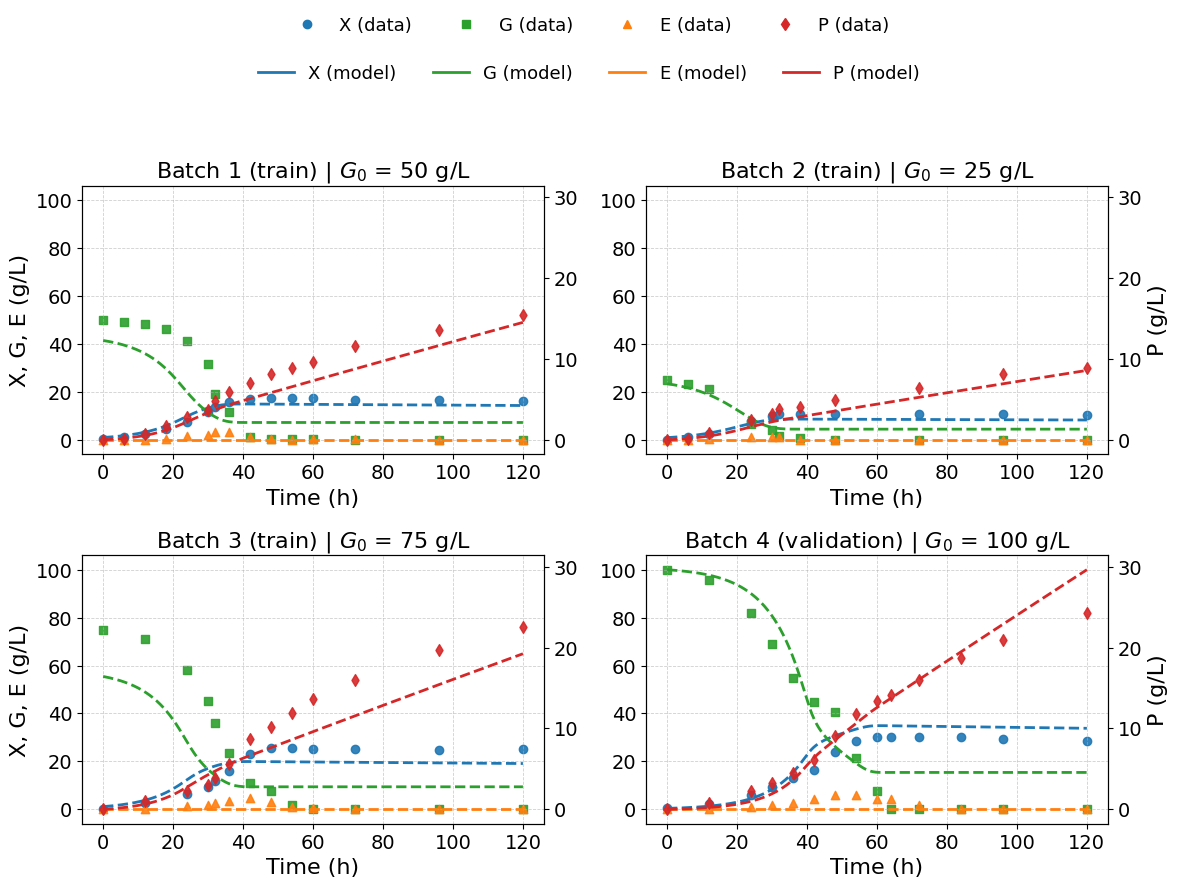

     --> NEW BEST for M2: 2.0789e+00


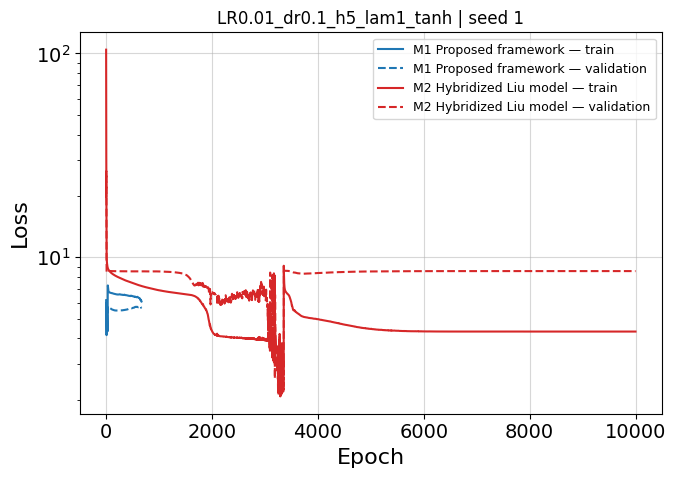

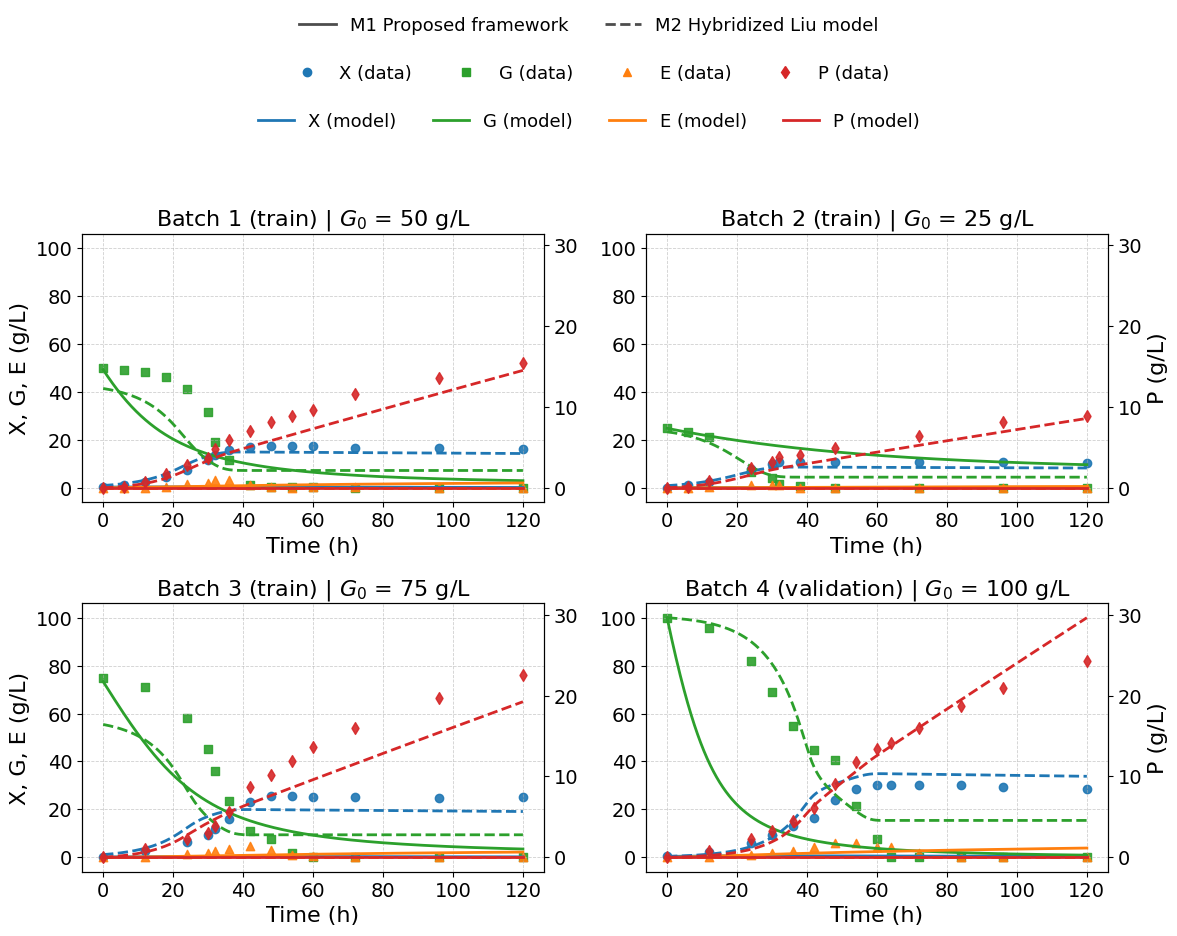

   [progress] 1/2 configs | 3.5 min | ETA 3.5 min

[2/2] LR=0.01 | dropout=0.1 | hidden=5 | lambda_IC=1 | act=relu
   --- seed 1 (1/1) ---
     M1:
        ep 81: DIVERGED -> aborted
     M1: DIVERGED at epoch 81


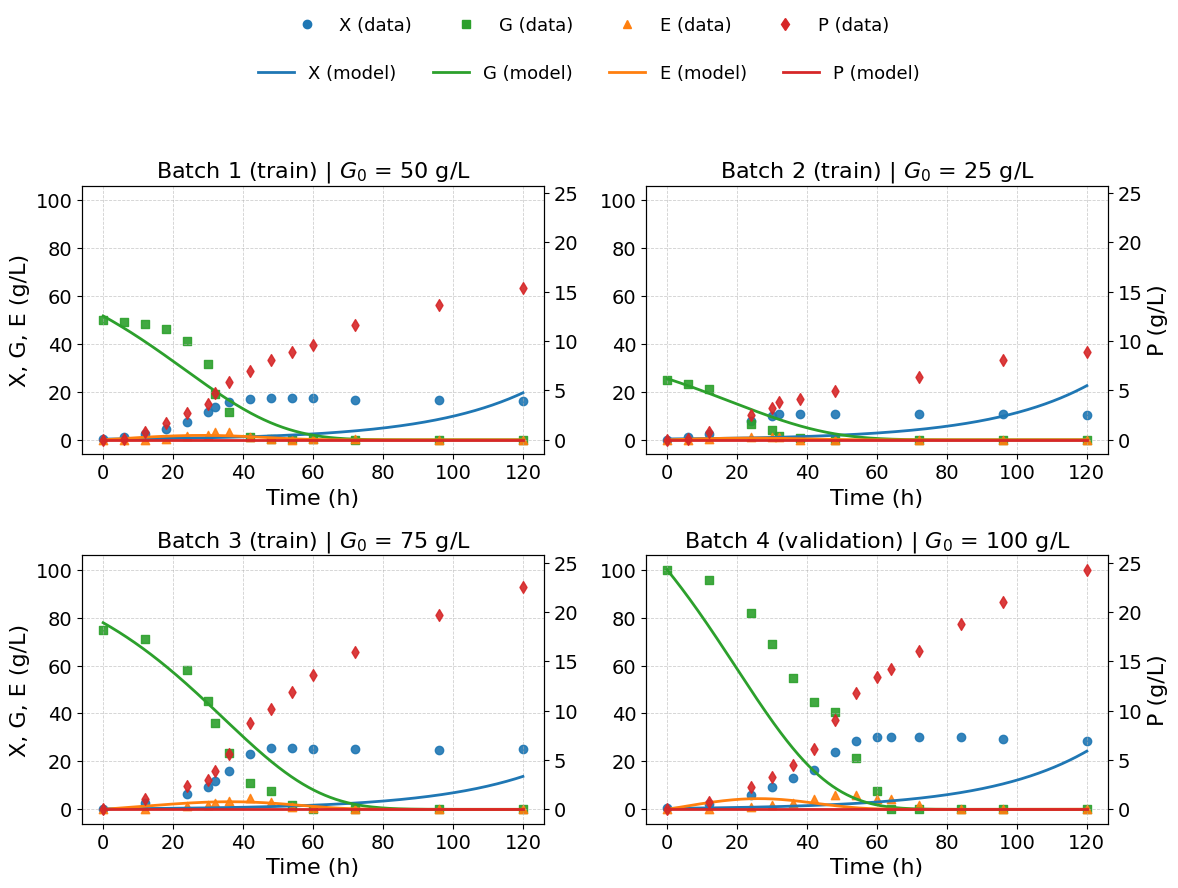

     --> NEW BEST for M1: 4.2231e+00
     M2:
        ep 400: train=5.401723, valid=7.741548
        ep 800: train=5.246442, valid=8.146917
        ep 1200: train=4.902898, valid=8.436220
        ep 1600: train=4.588338, valid=8.518852
        ep 2000: train=4.455150, valid=8.538218
        ep 2400: train=4.386949, valid=8.546351
        ep 2800: train=4.348175, valid=8.550680
        ep 3200: train=4.329495, valid=8.553496
        ep 3600: train=4.323913, valid=8.555273
        ep 4000: train=4.323019, valid=8.556149
        ep 4400: train=4.322927, valid=8.556585
        ep 4800: train=4.322923, valid=8.556480
        ep 5200: train=4.322924, valid=8.556485
        ep 5600: train=4.324094, valid=8.556649
        ep 6000: train=4.322918, valid=8.556540
        ep 6400: train=4.322930, valid=8.556459
        ep 6800: train=4.322918, valid=8.556481
        ep 7200: train=4.322917, valid=8.556433
        ep 7600: train=4.322922, valid=8.556613
        ep 8000: train=4.322920, valid=8.556

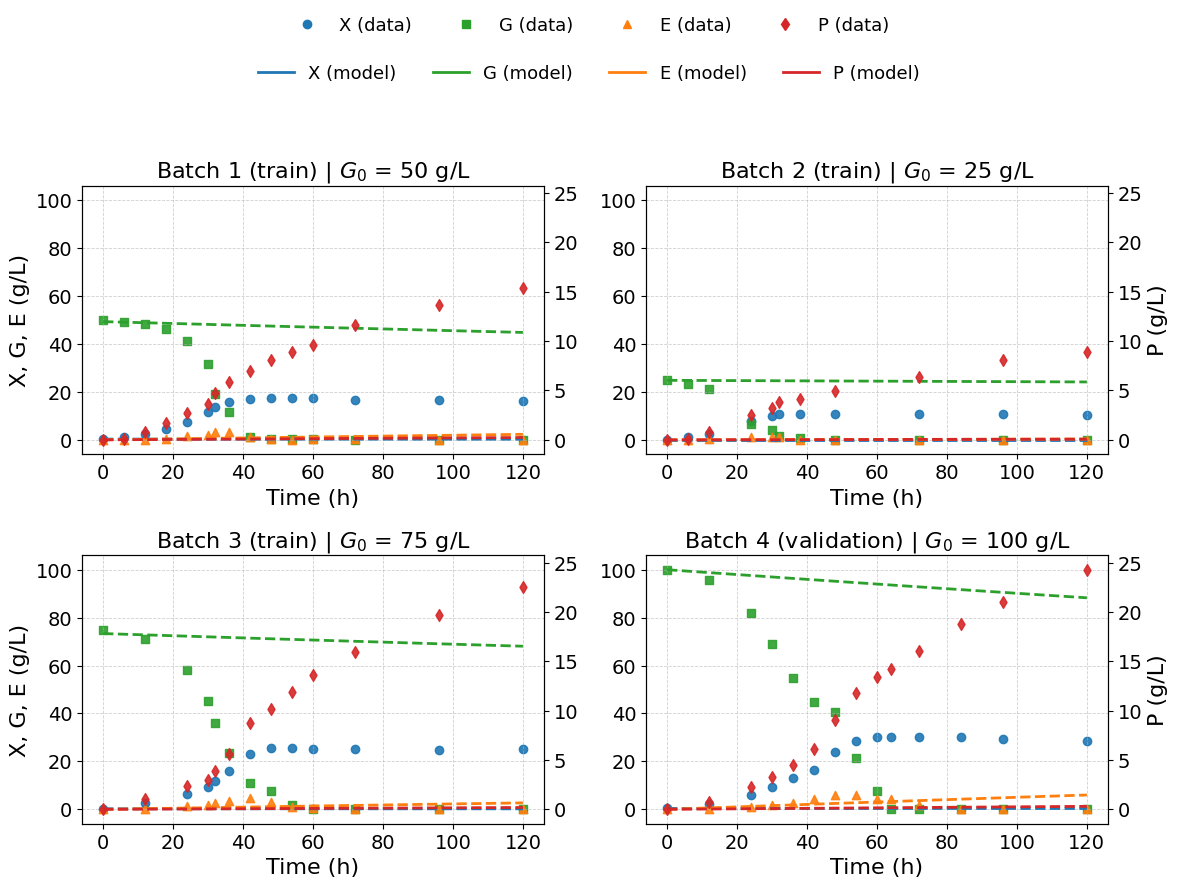

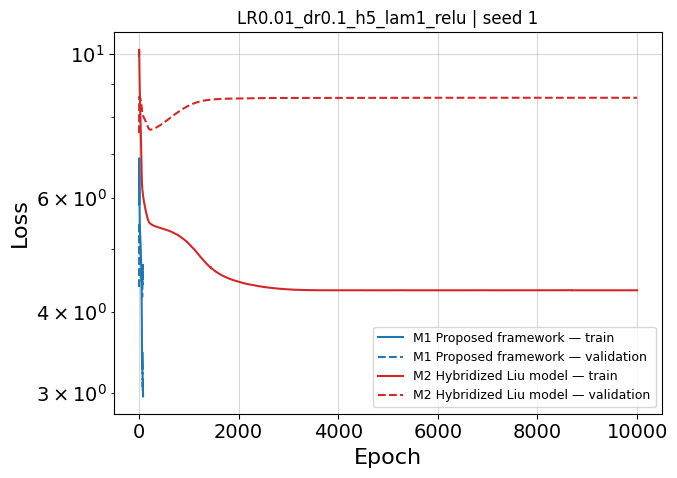

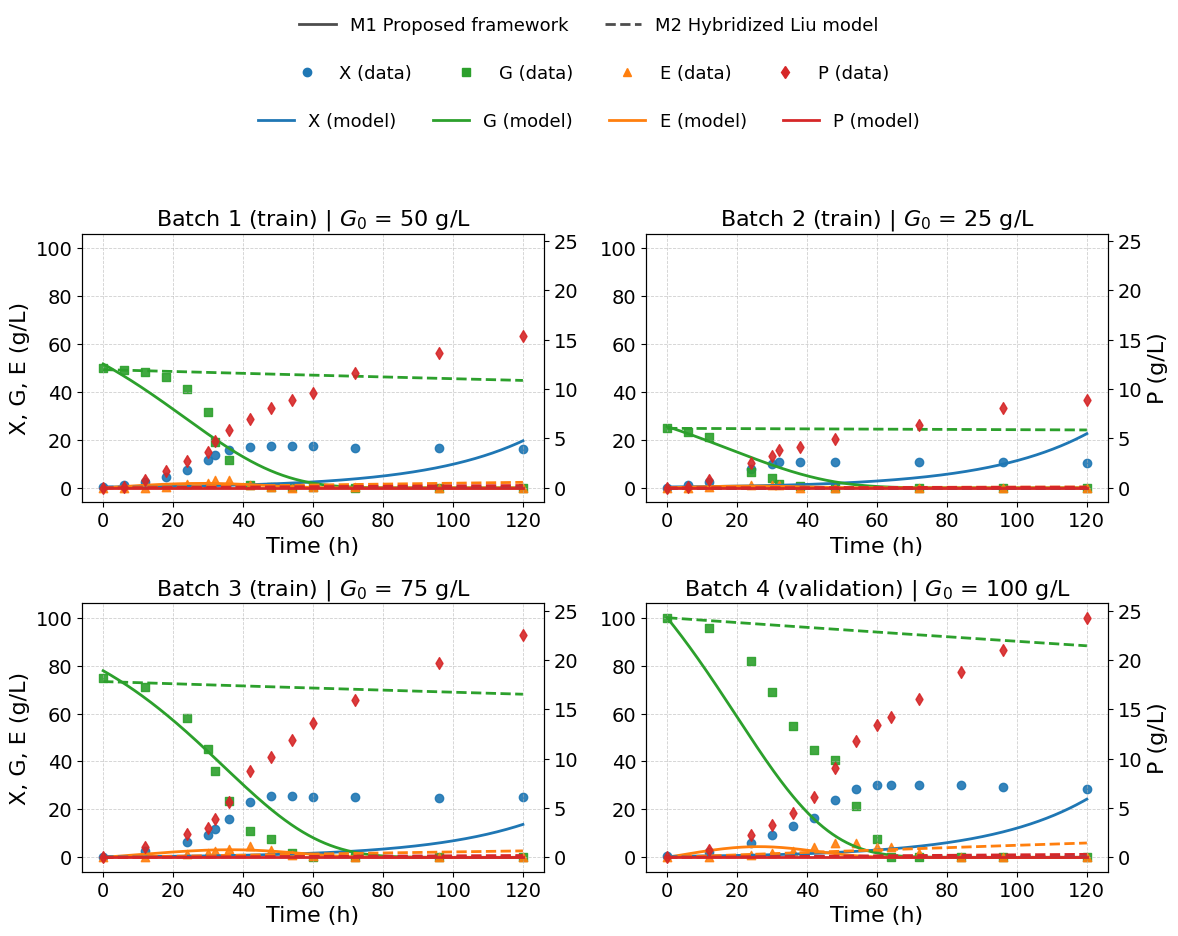

   [progress] 2/2 configs | 6.1 min | ETA 0.0 min

Sweep finished in 6.1 min.

M1 PROPOSED FRAMEWORK  (2 runs, 0 diverged)
Best 5 configurations by mean validation loss across seeds:
       LR   drop     hidden    act   n     val_mean      val_std
  1.0e-02   0.10          5   relu   1   4.2231e+00   0.0000e+00
  1.0e-02   0.10          5   tanh   1   4.6970e+00   0.0000e+00

Runs producing a negative concentration: 1 / 2

Excel written to: sweep_results_astaxanthin/sensitivity_M1.xlsx

M2 HYBRIDIZED LIU MODEL  (2 runs, 0 diverged)
Best 5 configurations by mean validation loss across seeds:
       LR   drop     hidden    act   n     val_mean      val_std
  1.0e-02   0.10          5   tanh   1   2.0789e+00   0.0000e+00
  1.0e-02   0.10          5   relu   1   7.5509e+00   0.0000e+00

Fitted mechanistic parameters across all non-diverged runs:
 parameter    n         mean          std     CV %        Liu
       k_d    2    0.0008436    0.0004244     50.3    0.00114
     alpha    2       


Best-run figure (M1):
  - sweep_results_astaxanthin/traj_best_M1_LR0.01_dr0.1_h5_lam1_relu_seed1.png
  - sweep_results_astaxanthin/traj_best_M1_LR0.01_dr0.1_h5_lam1_relu_seed1.eps
  - sweep_results_astaxanthin/traj_best_M1_LR0.01_dr0.1_h5_lam1_relu_seed1.svg



Best-run figure (M2):
  - sweep_results_astaxanthin/traj_best_M2_LR0.01_dr0.1_h5_lam1_tanh_seed1.png
  - sweep_results_astaxanthin/traj_best_M2_LR0.01_dr0.1_h5_lam1_tanh_seed1.eps
  - sweep_results_astaxanthin/traj_best_M2_LR0.01_dr0.1_h5_lam1_tanh_seed1.svg



Best-run overlay figure:
  - sweep_results_astaxanthin/traj_best_overlay_best_seed1.png
  - sweep_results_astaxanthin/traj_best_overlay_best_seed1.eps
  - sweep_results_astaxanthin/traj_best_overlay_best_seed1.svg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# ============================================================
# HYPERPARAMETER SWEEP — ASTAXANTHIN, TWO COMPETING HYBRID MODELS
# Paste this whole block into a single Colab cell.
#
# Requires in memory: raw_t, raw_X, raw_G, raw_E, raw_P
#
# For every (configuration, seed) the TWO models are trained back to back
# under identical conditions -- same optimizer, solver, data partition,
# minibatch strategy, dropout rate and random seed. The only thing that differs
# is the structure imposed a priori.
#
#   M1  "Proposed framework"                     (no reaction scheme assumed)
#         dX/dt = f1 X
#         dG/dt = f2 G X
#         dE/dt = f3 E X + g3 X
#         dP/dt = f4 P   + g4 X
#         FNN outputs: f1..f4 (free), g3, g4 (>= 0)
#         Mechanistic parameters: none
#
#   M2  "Hybridized Liu & Wu"                    (reaction scheme of Liu 2008)
#         reactions:  G -(rG)-> X ,  E -(rE)-> X ,  G -(rF)-> E
#         dX/dt = (rG + rE - kd) X
#         dG/dt = -(rG/Y_XG + rF/Y_EG) X
#         dE/dt = (rF - rE/Y_XE) X
#         dP/dt = alpha dX/dt + beta X            (Luedeking-Piret)
#         FNN outputs: rG, rE, rF (>= 0)
#         Fixed: Y_XG, Y_XE (data), Y_EG (stoichiometric)
#         Estimated with the weights: kd, alpha, beta
#
# M1 and M2 differ only in the structure imposed a priori: M2 retains the
# reaction scheme, the stoichiometry and the yield coefficients of Liu & Wu
# (2008) and replaces only the kinetic expressions by an FNN, whereas M1
# assumes no reaction scheme at all. This is the comparison the paper is about.
#
# Each model writes its OWN csv and its OWN Excel file. The estimated
# mechanistic parameters are recorded for every run, so their dispersion can be
# compared against the values published by Liu & Wu.
# ============================================================
import importlib.util, subprocess, sys
get_ipython().system('pip install -q openpyxl')  # noqa: F821  (Colab)


def _install_dependencies():
    def _has_gpu():
        try:
            return subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0
        except FileNotFoundError:
            return False
    jax_pkg = "jax[cuda12]" if _has_gpu() else "jax"
    print(f"Installing {jax_pkg}, diffrax and optax (first run only)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U",
                           jax_pkg, "diffrax", "optax"])


if importlib.util.find_spec("diffrax") is None:
    _install_dependencies()

import os, csv, re, time, pickle, itertools
import numpy as np

# ---- display setting must be known before the backend is chosen ----
SHOW_PLOTS = True             # True = save AND display inline; False = save only

import matplotlib
# Explicit in BOTH directions: if the cell ran earlier with SHOW_PLOTS = False,
# the Agg backend stays active for the rest of the session.
if SHOW_PLOTS:
    try:
        matplotlib.use("module://matplotlib_inline.backend_inline")
    except Exception:
        pass
else:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from jax import config
from jax.experimental.ode import odeint

try:
    import diffrax
    import optax
except ImportError:
    _install_dependencies()
    raise SystemExit(
        "\n=================================================================\n"
        "Dependencies reinstalled. NOW restart the session:\n"
        "  Runtime -> Restart session\n"
        "and run this same cell again (it will not reinstall anything).\n"
        "=================================================================")

print(f"jax {jax.__version__} | diffrax {diffrax.__version__} | optax {optax.__version__}")
print(f"Backend: {jax.default_backend()} | Devices: {jax.devices()}")
print(f"Matplotlib backend: {matplotlib.get_backend()} | SHOW_PLOTS={SHOW_PLOTS}")

# ========================================================
# (OPTIONAL) FORCE TPU BACKEND
# ========================================================
config.update("jax_platform_name", "tpu")
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=8"

# ========================================================
# 0. GENERAL SETTINGS
# ========================================================
MODELS = ["M1", "M2"]   # both are trained for every (config, seed)

TRAIN_MODE = "batch"          # "batch" or "global"
NUM_EPOCHS = 10000
EPS = 1.0e-8

SEED_START = 1
N_SEEDS = 1

# NOTE ON SEEDS. The resume logic keys on (model, config, seed), so N_SEEDS can
# be raised later and the sweep re-run: seeds already in the csv are skipped and
# only the new ones are trained. Sweep everything at 3 seeds, then deepen the
# configurations that matter to 10 -- a standard deviation over 3 seeds is a
# rough indication, not a number to put in a table.

# ---------- HYPERPARAMETER GRID  <<<< EDIT HERE >>>> ----------
GRID_LR         = [1e-2]
GRID_DROPOUT    = [0.1,]
GRID_LAMBDA_IC  = [1.0]
GRID_ACTIVATION = ["tanh", "relu"]      # hidden layers only
GRID_HIDDEN     = [[5]]
# --------------------------------------------------------------
# Only the HIDDEN-layer activation is swept. The output activations are
# structural, not tunable: the g_i (M1) and every reaction rate r (M2) are
# passed through a ReLU to keep them non-negative, and the f_i outputs of M1 are
# linear because f_1 must be allowed to go negative to represent biomass decay.

# --- ODE solver ---
SOLVER = "diffrax"            # "diffrax" (robust for sweeps) or "odeint"
ODE_RTOL = 1e-6
ODE_ATOL = 1e-7
ODE_MAX_STEPS = 4096
ODE_MXSTEP = 2000

# Zero-field pretraining of the network outputs
CALIB_STEPS = 1000
CALIB_LR = 1e-3

DIVERGENCE_THRESHOLD = 1e6

# Dataset splits
train_idxs = [0, 2, 3]
valid_idxs = [1]
test_idxs  = []

# --- mass-balance model (M2): fixed stoichiometry and yields ---
# Y_EG is the ethanol yield on glucose from C6H12O6 -> 2 C2H5OH + 2 CO2.
# It is the only coefficient with a strict stoichiometric basis, exactly as in
# Liu & Wu (2008), and is never fitted.
Y_EG_STOICH = 0.511
# Y_XG and Y_XE are computed DIRECTLY from the training batches at
# start-up (see compute_yields_from_training_data). Set YIELDS_OVERRIDE to a
# dict to bypass that, e.g. {"Y_XG": 0.372, "Y_XE": 0.324} for the values
# published by Liu & Wu.
YIELDS_OVERRIDE = None
# Initial guesses for the coefficients estimated jointly with the weights.
# k_d, alpha and beta all belong to M2; M1 has no mechanistic parameters.
MECH_INIT = {"k_d": 0.00114, "alpha": 0.342, "beta": 0.00698}

# Output paths (one csv + one Excel PER MODEL)
OUTDIR = "sweep_results_astaxanthin"
PLOTDIR = os.path.join(OUTDIR, "run_plots")
PARAMDIR = os.path.join(OUTDIR, "params")
for _d in (OUTDIR, PLOTDIR, PARAMDIR):
    os.makedirs(_d, exist_ok=True)


def csv_path(model):
    return os.path.join(OUTDIR, f"sweep_runs_{model}.csv")


def xlsx_path(model):
    return os.path.join(OUTDIR, f"sensitivity_{model}.xlsx")


PLOT_EACH_RUN = True          # per-model trajectory figure after every run
PLOT_OVERLAY = True           # all models on one trajectory figure
PLOT_LOSS_CURVES = True       # all models on one loss figure
VECTOR_FOR_BEST = True        # EPS + SVG for the overall best run of each model
SAVE_PARAMS = True            # pickle the best parameters of every run

CONFIGS = list(itertools.product(GRID_LR, GRID_DROPOUT, GRID_HIDDEN,
                                 GRID_LAMBDA_IC, GRID_ACTIVATION))
MAX_CONFIGS = None            # e.g. 2 for a smoke test; None = all

# ========================================================
# 1. DATA PREP
# ========================================================
t_batches = [jax.device_put(jnp.array(a)) for a in raw_t]          # noqa: F821
X_batches = [jax.device_put(jnp.array(a)) for a in raw_X]          # noqa: F821
G_batches = [jax.device_put(jnp.array(a)) for a in raw_G]          # noqa: F821
E_batches = [jax.device_put(jnp.array(a)) for a in raw_E]          # noqa: F821
P_batches = [jax.device_put(jnp.array(a)) for a in raw_P]          # noqa: F821


def _subset(idxs):
    return ([t_batches[i] for i in idxs], [X_batches[i] for i in idxs],
            [G_batches[i] for i in idxs], [E_batches[i] for i in idxs],
            [P_batches[i] for i in idxs])


t_train, X_train, G_train, E_train, P_train = _subset(train_idxs)
t_valid, X_valid, G_valid, E_valid, P_valid = _subset(valid_idxs)
t_test,  X_test,  G_test,  E_test,  P_test  = _subset(test_idxs)

N_STATES = 4
STATE_NAMES = ("X", "G", "E", "P")
N_OBS_TRAIN = int(sum(len(np.array(t)) for t in t_train) * N_STATES)

# ========================================================
# 1.1 MODEL REGISTRY
# ========================================================
MODEL_SPECS = {
    "M1": dict(
        label="M1 Proposed framework",
        n_outputs=6,                       # f1..f4, g3, g4
        output_names=("f1", "f2", "f3", "f4", "g3", "g4"),
        mech_names=(),                     # nothing estimated, nothing fixed
        fixed_yields=(),
    ),
    "M2": dict(
        label="M2 Hybridized Liu model",
        n_outputs=3,                       # rG, rE, rF
        output_names=("r_G", "r_E", "r_F"),
        mech_names=("k_d", "alpha", "beta"),
        fixed_yields=("Y_XG", "Y_XE", "Y_EG"),
    ),
}


def n_outputs_of(model):
    return MODEL_SPECS[model]["n_outputs"]


# ========================================================
# 1.2 YIELD COEFFICIENTS FROM THE TRAINING DATA
# ========================================================
def compute_yields_from_training_data(verbose=True):
    """Yield coefficients measured DIRECTLY from the training batches.

    This follows Liu & Wu (2008), who state that "the biomass yield coefficient
    on glucose and ethanol (Y_X/G and Y_X/E) were calculated directly from the
    experimental data during batch culture", while the ethanol yield on glucose
    Y_E/G = 0.511 comes from the stoichiometry C6H12O6 -> 2 C2H5OH + 2 CO2.
    No carbon balance and no derived coefficient is used here.

        Y_XG : glucose-consumption phase, from t = 0 up to the ethanol peak
               (i.e. while glucose is the carbon source).  Y_XG = dX / (-dG)
        Y_XE : diauxic phase, after the ethanol peak with glucose exhausted, so
               all growth comes from ethanol.  Y_XE = dX / (-dE)
    """
    if YIELDS_OVERRIDE:
        if verbose:
            print(f"Yields overridden by hand: {YIELDS_OVERRIDE}")
        out = dict(Y_EG=Y_EG_STOICH)
        out.update(YIELDS_OVERRIDE)
        return out

    yxg_list, yxe_list = [], []
    rows = []
    for i in range(len(t_train)):
        X = np.array(X_train[i], float)
        G = np.array(G_train[i], float)
        E = np.array(E_train[i], float)

        peak = int(np.argmax(E))                  # end of the glucose phase
        g_thresh = 0.05 * max(G[0], EPS)          # "glucose exhausted"

        # ---- Y_XG : growth on glucose, up to the ethanol peak ----
        yxg = np.nan
        if peak >= 1:
            dG = G[0] - G[peak]
            dX = X[peak] - X[0]
            if dG > 1e-6 and dX > 0:
                yxg = dX / dG
        if np.isfinite(yxg) and 0.0 < yxg < 1.0:
            yxg_list.append(yxg)

        # ---- Y_XE : growth on ethanol, diauxic phase ----
        mask = np.zeros_like(E, dtype=bool)
        mask[peak:] = True
        mask &= (G < g_thresh)
        idx = np.where(mask)[0]
        yxe = np.nan
        if idx.size >= 2:
            a, b = idx[0], idx[-1]
            dE = E[a] - E[b]
            dX = X[b] - X[a]
            if dE > 1e-6 and dX > 0:
                yxe = dX / dE
        if np.isfinite(yxe):
            yxe_list.append(yxe)

        rows.append(dict(batch=train_idxs[i], G0=G[0], E_peak=E[peak],
                         Y_XG=yxg, Y_XE=yxe))

    Y_XG = float(np.mean(yxg_list)) if yxg_list else 0.372   # fall back to Liu
    Y_XE = float(np.mean(yxe_list)) if yxe_list else 0.324   # fall back to Liu

    if verbose:
        print("\nYield coefficients measured on the TRAINING batches")
        print(f"{'batch':>6} {'G0':>7} {'E_peak':>8} {'Y_XG':>9} {'Y_XE':>9}")
        for r in rows:
            f = lambda v: f"{v:9.4f}" if np.isfinite(v) else f"{'--':>9}"
            print(f"{r['batch']:>6} {r['G0']:>7.1f} {r['E_peak']:>8.2f} "
                  f"{f(r['Y_XG'])} {f(r['Y_XE'])}")
        print(f"  mean Y_XG = {Y_XG:.4f}   (Liu & Wu report 0.372)")
        print(f"  mean Y_XE = {Y_XE:.4f}   (Liu & Wu report 0.324)")
        print(f"  Y_EG      = {Y_EG_STOICH:.4f}   (stoichiometric, never fitted)")

    return dict(Y_EG=Y_EG_STOICH, Y_XG=Y_XG, Y_XE=Y_XE)


YIELDS = compute_yields_from_training_data()

# ========================================================
# 1.3 START-UP BANNER
# ========================================================
def _n_weights(hidden, n_in, n_out):
    sizes = [n_in] + list(hidden) + [n_out]
    return sum(sizes[i + 1] * sizes[i] + sizes[i + 1] for i in range(len(sizes) - 1))


print("\n" + "=" * 78)
print("FULL SWEEP: " + " x ".join([
    f"{len(GRID_LR)} LR", f"{len(GRID_DROPOUT)} dropout",
    f"{len(GRID_HIDDEN)} arch", f"{len(GRID_LAMBDA_IC)} lambda",
    f"{len(GRID_ACTIVATION)} activation"]) + f" = {len(CONFIGS)} configurations")
print(f"Models: {', '.join(MODELS)} | seeds: {N_SEEDS} | "
      f"total trainings: {len(CONFIGS) * N_SEEDS * len(MODELS)}")
print("-" * 78)
print(f"Training measurements: {N_OBS_TRAIN} "
      f"({len(t_train)} experiments x {N_STATES} state variables)")
for m in MODELS:
    no = n_outputs_of(m)
    print(f"\n  {MODEL_SPECS[m]['label']} ({no} network outputs, "
          f"{len(MODEL_SPECS[m]['mech_names'])} fitted mechanistic parameters, "
          f"{len(MODEL_SPECS[m]['fixed_yields'])} fixed coefficients)")
    print(f"  {'hidden':>14} {'weights':>9} {'obs/param':>11}")
    for _h in GRID_HIDDEN:
        _nw = _n_weights(_h, N_STATES, no)
        print(f"  {'-'.join(map(str, _h)):>14} {_nw:>9} {N_OBS_TRAIN / _nw:>11.2f}")
print("=" * 78 + "\n")

# ========================================================
# 1.4 Helpers
# ========================================================
def count_params_pytree(pytree):
    leaves, _ = jax.tree_util.tree_flatten(pytree)
    total = 0
    for l in leaves:
        if isinstance(l, (np.ndarray, jnp.ndarray)):
            total += int(np.prod(np.array(l.shape)))
        else:
            total += 1
    return total


def arch_string(layer_sizes):
    return "-".join(str(n) for n in layer_sizes)


def pytree_snapshot_to_cpu(pytree):
    return jax.tree_util.tree_map(lambda x: np.array(x), pytree)


def ensure_dir(p):
    os.makedirs(p, exist_ok=True)


# ========================================================
# 2. NEURAL NETWORK
# ========================================================
HIDDEN_ACTIVATIONS = {
    "tanh": jnp.tanh,
    "relu": jax.nn.relu,
    "softplus": jax.nn.softplus,
}


def init_net_params(rng_key, layer_sizes):
    params = {}
    keys = jax.random.split(rng_key, 2 * (len(layer_sizes) - 1))
    k = 0
    for i in range(len(layer_sizes) - 1):
        n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
        params[f"W{i}"] = jax.random.uniform(keys[k], (n_out, n_in), minval=-0.1, maxval=0.1)
        params[f"b{i}"] = jax.random.uniform(keys[k + 1], (n_out,), minval=-0.1, maxval=0.1)
        k += 2
    return params


def sample_hidden_masks(net_params, rate, rng):
    if rate is None or rate <= 0.0:
        return None
    keep = 1.0 - rate
    masks = []
    num_layers = len(net_params) // 2
    for i in range(num_layers - 1):
        size = net_params[f"b{i}"].shape
        rng, ki = jax.random.split(rng)
        masks.append(jax.random.bernoulli(ki, p=keep, shape=size).astype(jnp.float32) / keep)
    return masks


def neural_network(net_params, y, *, train=False, masks=None, activation="tanh"):
    phi = HIDDEN_ACTIVATIONS[activation]
    a = y
    num_layers = len(net_params) // 2
    for i in range(num_layers):
        W, b = net_params[f"W{i}"], net_params[f"b{i}"]
        z = W @ a + b
        if i < num_layers - 1:
            a = phi(z)
            if train and (masks is not None):
                a = a * masks[i]
        else:
            a = z
    return a


# ========================================================
# 2.1 MECHANISTIC PARAMETERS (M2)
# ========================================================
# Stored as unconstrained reals and mapped through softplus, so the fitted
# values stay positive no matter what the optimizer does.
def _inv_softplus(y):
    y = float(y)
    return float(np.log(np.expm1(max(y, 1e-8))))


def init_mech_params(model):
    if not MODEL_SPECS[model]["mech_names"]:
        return {}
    return {f"raw_{k}": jnp.array(_inv_softplus(MECH_INIT[k]))
            for k in MODEL_SPECS[model]["mech_names"]}


def mech_values(mech_params, model):
    """Constrained (physical) values of the fitted mechanistic parameters."""
    if not MODEL_SPECS[model]["mech_names"]:
        return {}
    return {k: jax.nn.softplus(mech_params[f"raw_{k}"])
            for k in MODEL_SPECS[model]["mech_names"]}


# ========================================================
# 2.2 THE TWO RIGHT-HAND SIDES
# ========================================================
def model_jax(net_params, mech_params, y, t, *, model="M1",
              train=False, masks=None, activation="tanh"):
    X, G, E, P = y
    out = neural_network(net_params, jnp.array([X, G, E, P]),
                         train=train, masks=masks, activation=activation)

    # ---------- M1: proposed framework, no reaction scheme ----------
    if model == "M1":
        f1, f2, f3, f4, g3, g4 = out
        g3c, g4c = jax.nn.relu(g3), jax.nn.relu(g4)
        return jnp.stack([
            f1 * X,
            f2 * G * X,
            (f3 * E + g3c) * X,
            (f4 * P + g4c * X),
        ])

    # ---------- M2: hybridized Liu & Wu ----------
    # reactions  G -(rG)-> X ,  E -(rE)-> X ,  G -(rF)-> E
    # astaxanthin follows the Luedeking-Piret correlation and does not consume
    # glucose, exactly as in the original model.
    if model == "M2":
        rG, rE, rF = jax.nn.relu(out)             # reaction rates are non-negative
        mv = mech_values(mech_params, model)
        k_d, alpha, beta = mv["k_d"], mv["alpha"], mv["beta"]
        Y_XG, Y_XE, Y_EG = YIELDS["Y_XG"], YIELDS["Y_XE"], YIELDS["Y_EG"]
        growth = rG + rE - k_d                    # net specific growth rate
        return jnp.stack([
            growth * X,
            -(rG / Y_XG + rF / Y_EG) * X,
            (rF - rE / Y_XE) * X,
            (alpha * growth + beta) * X,          # dP/dt = alpha dX/dt + beta X
        ])

    raise ValueError(f"unknown model '{model}'")


# ========================================================
# 2.3 PREDICT
# ========================================================
if SOLVER == "diffrax":
    def predict(net_params, mech_params, t_array, X0, G0, *, E0=0.0, P0=0.0,
                model="M1", train=False, masks=None, activation="tanh"):
        def rhs(t, y, args):
            return model_jax(net_params, mech_params, y, t, model=model,
                             train=train, masks=masks, activation=activation)
        sol = diffrax.diffeqsolve(
            diffrax.ODETerm(rhs), diffrax.Tsit5(),
            t0=t_array[0], t1=t_array[-1], dt0=None,
            y0=jnp.array([X0, G0, E0, P0]),
            saveat=diffrax.SaveAt(ts=t_array),
            stepsize_controller=diffrax.PIDController(rtol=ODE_RTOL, atol=ODE_ATOL),
            max_steps=ODE_MAX_STEPS,
            adjoint=diffrax.RecursiveCheckpointAdjoint(),
            throw=False,
        )
        ys = sol.ys
        return ys[:, 0], ys[:, 1], ys[:, 2], ys[:, 3]
elif SOLVER == "odeint":
    def predict(net_params, mech_params, t_array, X0, G0, *, E0=0.0, P0=0.0,
                model="M1", train=False, masks=None, activation="tanh"):
        def rhs(y, tt):
            return model_jax(net_params, mech_params, y, tt, model=model,
                             train=train, masks=masks, activation=activation)
        sol = odeint(rhs, jnp.array([X0, G0, E0, P0]), t_array,
                     rtol=ODE_RTOL, atol=ODE_ATOL, mxstep=ODE_MXSTEP)
        return sol[:, 0], sol[:, 1], sol[:, 2], sol[:, 3]
else:
    raise ValueError("SOLVER must be 'diffrax' or 'odeint'")

predict = jax.jit(predict, static_argnames=("model", "train", "activation"))


# ========================================================
# 2.4 INITIAL CONDITIONS VIA LOG-OFFSETS
# ========================================================
def init_ic_offset_params_from_data(X_train, G_train):
    n = len(X_train)
    X0_meas = jnp.array([float(np.array(X_train[i])[0]) for i in range(n)])
    G0_meas = jnp.array([float(np.array(G_train[i])[0]) for i in range(n)])
    return ({"alpha_X": jnp.zeros_like(X0_meas), "alpha_G": jnp.zeros_like(G0_meas)},
            {"X0": X0_meas, "G0": G0_meas})


def ic_for_train_batch(params, idx):
    X0 = params["ic_meas"]["X0"][idx] * jnp.exp(params["ic_alpha"]["alpha_X"][idx])
    G0 = params["ic_meas"]["G0"][idx] * jnp.exp(params["ic_alpha"]["alpha_G"][idx])
    return X0, G0, jnp.array(0.0), jnp.array(0.0)


# ========================================================
# 3. LOSSES
# ========================================================
def safe_rel(pred, obs):
    return (pred - obs) / jnp.maximum(jnp.mean(jnp.abs(obs)), EPS)


def _mse4(Xp, Gp, Ep, Pp, Xo, Go, Eo, Po):
    return (jnp.mean(safe_rel(Xp, Xo) ** 2) + jnp.mean(safe_rel(Gp, Go) ** 2) +
            jnp.mean(safe_rel(Ep, Eo) ** 2) + jnp.mean(safe_rel(Pp, Po) ** 2))


def make_losses(model, dropout_rate, lambda_ic, activation):
    """Losses closed over THIS model and configuration, so jit never reuses a
    graph compiled with different settings."""

    def batch_loss_train(params, idx, rng):
        X0, G0, E0, P0 = ic_for_train_batch(params, idx)
        masks = sample_hidden_masks(params["net"], dropout_rate, rng)
        Xp, Gp, Ep, Pp = predict(params["net"], params["mech"], t_train[idx], X0, G0,
                                 E0=E0, P0=P0, model=model, train=True,
                                 masks=masks, activation=activation)
        data_loss = _mse4(Xp, Gp, Ep, Pp,
                          X_train[idx], G_train[idx], E_train[idx], P_train[idx])
        reg = lambda_ic * (params["ic_alpha"]["alpha_X"][idx] ** 2 +
                           params["ic_alpha"]["alpha_G"][idx] ** 2)
        return data_loss + reg

    batch_loss_train_jit = jax.jit(batch_loss_train, static_argnums=(1,))

    def global_train_loss(params, rng_key):
        total = 0.0
        for idx in range(len(t_train)):
            total += batch_loss_train(params, idx, jax.random.fold_in(rng_key, idx))
        return total / len(t_train)

    def batch_loss_train_eval(params, idx):
        X0, G0, E0, P0 = ic_for_train_batch(params, idx)
        Xp, Gp, Ep, Pp = predict(params["net"], params["mech"], t_train[idx], X0, G0,
                                 E0=E0, P0=P0, model=model, train=False,
                                 masks=None, activation=activation)
        return _mse4(Xp, Gp, Ep, Pp,
                     X_train[idx], G_train[idx], E_train[idx], P_train[idx])

    batch_loss_train_eval_jit = jax.jit(batch_loss_train_eval, static_argnums=(1,))

    def loss_heldout(net, mech, t_o, X_o, G_o, E_o, P_o):
        Xp, Gp, Ep, Pp = predict(net, mech, t_o, X_o[0], G_o[0], E0=0.0, P0=0.0,
                                 model=model, train=False, masks=None,
                                 activation=activation)
        return _mse4(Xp, Gp, Ep, Pp, X_o, G_o, E_o, P_o)

    loss_heldout_jit = jax.jit(loss_heldout)

    return (batch_loss_train_jit, global_train_loss,
            batch_loss_train_eval_jit, loss_heldout_jit)


# ========================================================
# 3.1 R^2 AND NON-NEGATIVITY DIAGNOSTICS
# ========================================================
def _r2(obs, pred):
    """R^2 of one variable in one experiment. NaN when undefined; negative
    values are legitimate and kept."""
    obs = np.asarray(obs, float).ravel()
    pred = np.asarray(pred, float).ravel()
    n = min(obs.size, pred.size)
    obs, pred = obs[:n], pred[:n]
    mask = np.isfinite(obs) & np.isfinite(pred)
    if mask.sum() < 2:
        return np.nan
    o, p = obs[mask], pred[mask]
    ss_tot = float(np.sum((o - o.mean()) ** 2))
    if ss_tot <= 0.0:
        return np.nan
    return float(1.0 - np.sum((o - p) ** 2) / ss_tot)


def evaluate_run(best_params, model, activation="tanh"):
    """R^2 per state variable and per experiment, plus the minimum concentration
    reached along each simulated trajectory.

    The minima are the empirical counterpart of the non-negativity proposition:
    M1 cannot produce negative states, whereas the mass-balance formulation
    M2 carries no such guarantee.
    """
    flat = {}
    if best_params is None:
        return flat

    net = jax.tree_util.tree_map(jnp.asarray, best_params["net"])
    mech = jax.tree_util.tree_map(jnp.asarray, best_params["mech"])
    ic_alpha = jax.tree_util.tree_map(jnp.asarray, best_params["ic_alpha"])
    ic_meas = jax.tree_util.tree_map(jnp.asarray, best_params["ic_meas"])

    blocks = [
        ("train", train_idxs, t_train, X_train, G_train, E_train, P_train, True),
        ("valid", valid_idxs, t_valid, X_valid, G_valid, E_valid, P_valid, False),
        ("test",  test_idxs,  t_test,  X_test,  G_test,  E_test,  P_test,  False),
    ]

    global_min = {v: np.inf for v in STATE_NAMES}

    for split, idxs, T, Xs, Gs, Es, Ps, learned_ic in blocks:
        pooled = {v: ([], []) for v in STATE_NAMES}
        for i in range(len(T)):
            if learned_ic:
                X0 = float(ic_meas["X0"][i] * jnp.exp(ic_alpha["alpha_X"][i]))
                G0 = float(ic_meas["G0"][i] * jnp.exp(ic_alpha["alpha_G"][i]))
            else:
                X0 = float(np.array(Xs[i])[0])
                G0 = float(np.array(Gs[i])[0])

            # dense grid so the minima are not missed between sampling times
            t_np = np.array(T[i], float)
            t_dense = jnp.linspace(float(t_np.min()), float(t_np.max()), 400)
            dense = predict(net, mech, t_dense, X0, G0, E0=0.0, P0=0.0,
                            model=model, train=False, masks=None,
                            activation=activation)
            for v, arr in zip(STATE_NAMES, dense):
                a = np.array(arr, float)
                if np.any(np.isfinite(a)):
                    global_min[v] = min(global_min[v], float(np.nanmin(a)))

            preds = predict(net, mech, T[i], X0, G0, E0=0.0, P0=0.0,
                            model=model, train=False, masks=None,
                            activation=activation)
            bidx = int(idxs[i])
            for v, o_arr, p_arr in zip(STATE_NAMES, (Xs[i], Gs[i], Es[i], Ps[i]), preds):
                o = np.array(o_arr, float)
                p = np.array(p_arr, float)
                flat[f"r2_{split}_b{bidx}_{v}"] = _r2(o, p)
                pooled[v][0].append(o)
                pooled[v][1].append(p)

        for v in STATE_NAMES:
            if pooled[v][0]:
                flat[f"r2_{split}_{v}"] = _r2(np.concatenate(pooled[v][0]),
                                              np.concatenate(pooled[v][1]))

    for v in STATE_NAMES:
        flat[f"min_{v}"] = (float(global_min[v]) if np.isfinite(global_min[v])
                            else np.nan)
    flat["any_negative_state"] = int(any(
        np.isfinite(flat[f"min_{v}"]) and flat[f"min_{v}"] < -1e-6
        for v in STATE_NAMES))
    return flat


# ========================================================
# 4. ZERO-FIELD PRETRAINING
# ========================================================
def calib_loss(net_params, points, n_out, activation="tanh"):
    target = jnp.zeros(n_out)

    def per_point(y):
        return jnp.mean((neural_network(net_params, y, train=False,
                                        activation=activation) - target) ** 2)
    return jnp.mean(jax.vmap(per_point)(points))


def calibrate_with_data(net_params, points, n_out, steps=CALIB_STEPS,
                        lr=CALIB_LR, activation="tanh", verbose=False):
    """Drive the network outputs to zero before training.

    For M1 this makes the whole vector field vanish. For M2 a residual
    -k_d X decay term remains, which is small and physically meaningful, so the
    starting point is still neutral.
    """
    optc = optax.adam(lr)
    opt_state = optc.init(net_params)

    @jax.jit
    def step(p, s):
        loss, grads = jax.value_and_grad(calib_loss)(p, points, n_out, activation)
        updates, s = optc.update(grads, s, p)
        return optax.apply_updates(p, updates), s, loss

    p = net_params
    for i in range(steps):
        p, opt_state, loss = step(p, opt_state)
        if verbose and i % 250 == 0:
            print(f"    [calib] step {i}, loss={loss:.4e}")
    return p


_calib_points = jnp.array([[x, g, e, p]
                           for Xb, Gb, Eb, Pb in zip(X_train, G_train, E_train, P_train)
                           for x, g, e, p in zip(np.array(Xb), np.array(Gb),
                                                 np.array(Eb), np.array(Pb))])

# ========================================================
# 5. PLOTTING
# ========================================================
COL_X, COL_G, COL_E, COL_P = "#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"
MODEL_LS = {"M1": "-", "M2": "--"}
MODEL_COL = {"M1": "#1f77b4", "M2": "#d62728"}

_PLOT_RC = {
    "font.size": 14, "axes.titlesize": 16, "axes.labelsize": 16,
    "xtick.labelsize": 14, "ytick.labelsize": 14,
    "legend.fontsize": 13, "figure.titlesize": 18,
}


def _dense_time_grid(t_np, n=800, pad_frac=0.0):
    t0, t1 = float(np.min(t_np)), float(np.max(t_np))
    if t1 <= t0:
        t1 = t0 + 1e-6
    span = t1 - t0
    return jnp.linspace(t0 - pad_frac * span, t1 + pad_frac * span, n)


def _with_pad(vmin, vmax, frac=0.06):
    span = vmax - vmin
    if span <= 0:
        base = max(abs(vmin), abs(vmax), 1.0)
        return vmin - base * frac, vmax + base * frac
    return vmin - span * frac, vmax + span * frac


def _simulate_panels(best_params, model, activation):
    """Dense simulation of every training and held-out batch, for plotting."""
    net = jax.tree_util.tree_map(jnp.asarray, best_params["net"])
    mech = jax.tree_util.tree_map(jnp.asarray, best_params["mech"])
    ic_alpha = jax.tree_util.tree_map(jnp.asarray, best_params["ic_alpha"])
    ic_meas = jax.tree_util.tree_map(jnp.asarray, best_params["ic_meas"])

    panels = ([(t_train[i], X_train[i], G_train[i], E_train[i], P_train[i], i, "train")
               for i in range(len(t_train))] +
              [(t_valid[i], X_valid[i], G_valid[i], E_valid[i], P_valid[i], None, "validation")
               for i in range(len(t_valid))])

    out = []
    for t_b, X_b, G_b, E_b, P_b, tr_idx, role in panels:
        t_obs = np.array(t_b)
        X_obs, G_obs = np.array(X_b), np.array(G_b)
        E_obs, P_obs = np.array(E_b), np.array(P_b)
        t_dense = _dense_time_grid(t_obs)
        if tr_idx is not None:
            X0 = float(ic_meas["X0"][tr_idx] * jnp.exp(ic_alpha["alpha_X"][tr_idx]))
            G0 = float(ic_meas["G0"][tr_idx] * jnp.exp(ic_alpha["alpha_G"][tr_idx]))
        else:
            X0, G0 = float(X_obs[0]), float(G_obs[0])
        Xp, Gp, Ep, Pp = predict(net, mech, t_dense, X0, G0, E0=0.0, P0=0.0,
                                 model=model, train=False, masks=None,
                                 activation=activation)
        out.append(dict(t_obs=t_obs, t_dense=np.array(t_dense),
                        X_obs=X_obs, G_obs=G_obs, E_obs=E_obs, P_obs=P_obs,
                        X_pred=np.array(Xp), G_pred=np.array(Gp),
                        E_pred=np.array(Ep), P_pred=np.array(Pp),
                        G0=int(round(float(G_obs[0]))), role=role))
    return out


def _axis_limits(all_panels):
    left, right = [], []
    for panels in all_panels:
        for e in panels:
            left += [e["X_obs"], e["G_obs"], e["E_obs"],
                     e["X_pred"], e["G_pred"], e["E_pred"]]
            right += [e["P_obs"], e["P_pred"]]
    f = lambda arrs, fn: fn([fn(a[np.isfinite(a)]) if np.any(np.isfinite(a)) else 0.0
                             for a in arrs])
    return (_with_pad(f(left, np.min), f(left, np.max)),
            _with_pad(f(right, np.min), f(right, np.max)))


def plot_trajectories(panels_by_model, tag, seed, outdir=PLOTDIR,
                      vector=False, show=False, suffix=""):
    """One figure with all batches. If more than one model is passed they are
    overlaid: solid for M1 and dashed for M2."""
    models = list(panels_by_model)
    if not models:
        return []
    n_panels = len(panels_by_model[models[0]])
    if n_panels == 0:
        return []

    (left_lo, left_hi), (right_lo, right_hi) = _axis_limits(panels_by_model.values())
    ncols = 2 if n_panels > 1 else 1
    nrows = int(np.ceil(n_panels / ncols))

    with plt.rc_context(_PLOT_RC):
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows),
                                 squeeze=False)
        axes = axes.ravel()

        for i in range(n_panels):
            ax1 = axes[i]
            ax2 = ax1.twinx()
            ax1.set_ylim(left_lo, left_hi)
            ax2.set_ylim(right_lo, right_hi)

            for m in models:
                e = panels_by_model[m][i]
                ls = MODEL_LS.get(m, "-")
                ax1.plot(e["t_dense"], e["X_pred"], ls, color=COL_X, lw=2)
                ax1.plot(e["t_dense"], e["G_pred"], ls, color=COL_G, lw=2)
                ax1.plot(e["t_dense"], e["E_pred"], ls, color=COL_E, lw=2)
                ax2.plot(e["t_dense"], e["P_pred"], ls, color=COL_P, lw=2)

            e = panels_by_model[models[0]][i]
            ax1.scatter(e["t_obs"], e["X_obs"], marker='o', color=COL_X, alpha=0.9)
            ax1.scatter(e["t_obs"], e["G_obs"], marker='s', color=COL_G, alpha=0.9)
            ax1.scatter(e["t_obs"], e["E_obs"], marker='^', color=COL_E, alpha=0.9)
            ax2.scatter(e["t_obs"], e["P_obs"], marker='d', color=COL_P, alpha=0.9)

            ax1.set_title(f"Batch {i+1} ({e['role']}) | $G_0$ = {e['G0']} g/L")
            if i % ncols == 0:
                ax1.set_ylabel("X, G, E (g/L)")
            if i % ncols == ncols - 1:
                ax2.set_ylabel("P (g/L)")
            ax1.set_xlabel("Time (h)")
            ax1.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

        for j in range(n_panels, len(axes)):
            axes[j].axis("off")

        legend_state = [Line2D([0], [0], color=c, lw=2, label=f"{n} (model)")
                        for n, c in zip(STATE_NAMES, (COL_X, COL_G, COL_E, COL_P))]
        legend_data = [Line2D([0], [0], color=c, marker=mk, lw=0, label=f"{n} (data)")
                       for n, c, mk in zip(STATE_NAMES,
                                           (COL_X, COL_G, COL_E, COL_P),
                                           ('o', 's', '^', 'd'))]
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        fig.legend(handles=legend_state, loc='lower center', ncol=4,
                   frameon=False, bbox_to_anchor=(0.5, 1.0))
        fig.legend(handles=legend_data, loc='lower center', ncol=4,
                   frameon=False, bbox_to_anchor=(0.5, 1.06))
        if len(models) > 1:
            legend_model = [Line2D([0], [0], color="0.3", lw=2, ls=MODEL_LS.get(m, "-"),
                                   label=MODEL_SPECS[m]["label"]) for m in models]
            fig.legend(handles=legend_model, loc='lower center', ncol=len(models),
                       frameon=False, bbox_to_anchor=(0.5, 1.12))

        ensure_dir(outdir)
        base = os.path.join(outdir, f"traj{suffix}_{tag}_seed{seed}")
        saved = [base + ".png"]
        fig.savefig(saved[0], dpi=150, bbox_inches="tight")
        if vector:
            for ext in ("eps", "svg"):
                fig.savefig(f"{base}.{ext}", format=ext, dpi=600, bbox_inches="tight")
                saved.append(f"{base}.{ext}")
        if show:
            plt.show()
        plt.close(fig)
    return saved


def plot_losses(histories, tag, seed, outdir=PLOTDIR, show=False):
    """Training and validation loss of every model on a single figure."""
    if not histories:
        return None
    with plt.rc_context(_PLOT_RC):
        fig = plt.figure(figsize=(7, 5))
        for m, (tr, va) in histories.items():
            if len(tr) == 0:
                continue
            ep = np.arange(1, len(tr) + 1)
            c = MODEL_COL.get(m, None)
            plt.plot(ep, tr, "-", color=c, lw=1.5,
                     label=f"{MODEL_SPECS[m]['label']} — train")
            plt.plot(ep, va, "--", color=c, lw=1.5,
                     label=f"{MODEL_SPECS[m]['label']} — validation")
        plt.yscale("log")
        plt.xlabel("Epoch"); plt.ylabel("Loss")
        plt.title(f"{tag} | seed {seed}", fontsize=12)
        plt.legend(fontsize=9); plt.grid(True, alpha=0.5); plt.tight_layout()
        ensure_dir(outdir)
        path = os.path.join(outdir, f"loss_{tag}_seed{seed}.png")
        fig.savefig(path, dpi=150)
        if show:
            plt.show()
        plt.close(fig)
    return path


# ========================================================
# 6. SINGLE TRAINING (one model, one configuration, one seed)
# ========================================================
def train_one(model, seed, lr, dropout, hidden, lambda_ic, activation):
    spec = MODEL_SPECS[model]
    layer_sizes = [N_STATES] + list(hidden) + [spec["n_outputs"]]
    tag = (f"LR{lr:g}_dr{dropout:g}_h{'-'.join(map(str, hidden))}"
           f"_lam{lambda_ic:g}_{activation}")

    rng_master = jax.random.PRNGKey(seed)
    np.random.seed(seed)
    t0_cpu, t0_wall = time.process_time(), time.perf_counter()

    net_params = init_net_params(jax.random.fold_in(rng_master, 0), layer_sizes)
    net_params = calibrate_with_data(net_params, _calib_points, spec["n_outputs"],
                                     activation=activation)
    n_net_params = count_params_pytree(net_params)

    ic_alpha, ic_meas = init_ic_offset_params_from_data(X_train, G_train)
    params = {"net": net_params, "mech": init_mech_params(model),
              "ic_alpha": ic_alpha, "ic_meas": ic_meas}

    (batch_loss_train_jit, global_train_loss,
     batch_loss_train_eval_jit, loss_heldout_jit) = make_losses(
        model, dropout, lambda_ic, activation)

    def eval_avg_train_loss(p):
        v = [float(batch_loss_train_eval_jit(p, i)) for i in range(len(t_train))]
        return float(np.mean(v)) if v else np.nan

    def eval_split(net, mech, T, Xs, Gs, Es, Ps):
        v = [float(loss_heldout_jit(net, mech, T[i], Xs[i], Gs[i], Es[i], Ps[i]))
             for i in range(len(T))]
        return (float(np.mean(v)) if v else np.nan), v

    def _blown_up(tr, va):
        return (not (np.isfinite(tr) and np.isfinite(va))
                or tr > DIVERGENCE_THRESHOLD or va > DIVERGENCE_THRESHOLD)

    opt = optax.adam(lr)
    opt_state = opt.init(params)

    train_history, valid_history = [], []
    best_val, best_epoch, best_params = np.inf, None, None
    diverged = False

    if TRAIN_MODE == "batch":
        def train_step(params, opt_state, idx, rng):
            grads = jax.grad(batch_loss_train_jit)(params, idx, rng)
            updates, opt_state = opt.update(grads, opt_state, params)
            return optax.apply_updates(params, updates), opt_state
        train_step = jax.jit(train_step, static_argnums=(2,))

        for epoch in range(1, NUM_EPOCHS + 1):
            epoch_key = jax.random.fold_in(rng_master, epoch)
            perm = np.array(jax.random.permutation(epoch_key, len(t_train)))
            for idx in perm:
                params, opt_state = train_step(
                    params, opt_state, int(idx),
                    jax.random.fold_in(epoch_key, int(idx)))

            tr = eval_avg_train_loss(params)
            va, _ = eval_split(params["net"], params["mech"],
                               t_valid, X_valid, G_valid, E_valid, P_valid)
            train_history.append(tr); valid_history.append(va)

            if _blown_up(tr, va):
                diverged = True
                print(f"        ep {epoch}: DIVERGED -> aborted")
                break
            if va < best_val:
                best_val, best_epoch = float(va), epoch
                best_params = pytree_snapshot_to_cpu(params)
            if epoch % 400 == 0:
                print(f"        ep {epoch}: train={tr:.6f}, valid={va:.6f}")

    elif TRAIN_MODE == "global":
        # jax.grad deliberately NOT jitted here (TPU compiler issue).
        for epoch in range(1, NUM_EPOCHS + 1):
            epoch_key = jax.random.fold_in(rng_master, epoch)
            grads = jax.grad(global_train_loss)(params, epoch_key)
            updates, opt_state = opt.update(grads, opt_state, params)
            params = optax.apply_updates(params, updates)

            tr = eval_avg_train_loss(params)
            va, _ = eval_split(params["net"], params["mech"],
                               t_valid, X_valid, G_valid, E_valid, P_valid)
            train_history.append(tr); valid_history.append(va)

            if _blown_up(tr, va):
                diverged = True
                print(f"        ep {epoch}: DIVERGED -> aborted")
                break
            if va < best_val:
                best_val, best_epoch = float(va), epoch
                best_params = pytree_snapshot_to_cpu(params)
            if epoch % 400 == 0:
                print(f"        ep {epoch}: train={tr:.6f}, valid={va:.6f}")
    else:
        raise ValueError("TRAIN_MODE must be 'batch' or 'global'")

    cpu_time_s = time.process_time() - t0_cpu
    wall_time_s = time.perf_counter() - t0_wall
    train_history = np.array(train_history, float)
    valid_history = np.array(valid_history, float)

    diag = evaluate_run(best_params, model, activation=activation)

    if SAVE_PARAMS and best_params is not None:
        ensure_dir(PARAMDIR)
        with open(os.path.join(PARAMDIR, f"{model}_{tag}_seed{seed}.pkl"), "wb") as fh:
            pickle.dump({"params": best_params, "model": model, "tag": tag,
                         "seed": seed, "layer_sizes": layer_sizes,
                         "activation": activation, "yields": YIELDS}, fh)

    test_mean, test_per_batch, ic_dev = np.nan, [np.nan] * len(t_test), np.nan
    if best_params is not None:
        if len(t_test):
            bn = jax.tree_util.tree_map(jnp.asarray, best_params["net"])
            bm = jax.tree_util.tree_map(jnp.asarray, best_params["mech"])
            test_mean, test_per_batch = eval_split(bn, bm, t_test, X_test,
                                                   G_test, E_test, P_test)
        aX = np.array(best_params["ic_alpha"]["alpha_X"])
        aG = np.array(best_params["ic_alpha"]["alpha_G"])
        ic_dev = float(np.sqrt(np.mean(aX ** 2 + aG ** 2)))

    _clean = lambda x: float(x) if np.isfinite(x) else np.nan
    n_mech_fitted = len(spec["mech_names"])
    n_fitted = n_net_params + n_mech_fitted + 2 * len(t_train)

    row = {
        "model": model, "model_label": spec["label"],
        "learning_rate": lr, "dropout": dropout,
        "hidden_layers": "-".join(map(str, hidden)), "lambda_IC": lambda_ic,
        "activation": activation, "architecture": arch_string(layer_sizes),
        "n_net_parameters": n_net_params,
        "n_mech_fitted": n_mech_fitted,
        "n_fitted_parameters": n_fitted,
        "n_obs_train": N_OBS_TRAIN,
        "obs_per_parameter": round(N_OBS_TRAIN / n_net_params, 3),
        "seed": seed,
        "diverged": int(diverged), "epochs_completed": len(train_history),
        "best_epoch": best_epoch, "best_validation_loss": _clean(best_val),
        "train_loss_at_best": _clean(train_history[best_epoch - 1]) if best_epoch else np.nan,
        "test_loss_at_best": _clean(test_mean),
        "final_train_loss": _clean(train_history[-1]) if train_history.size else np.nan,
        "final_validation_loss": _clean(valid_history[-1]) if valid_history.size else np.nan,
        "ic_deviation_rms": _clean(ic_dev),
        "cpu_time_s": float(cpu_time_s), "wall_time_s": float(wall_time_s),
    }
    for i, v in enumerate(test_per_batch):
        row[f"test_loss_batch_{test_idxs[i]}"] = _clean(v)

    # ---- mechanistic coefficients ----
    # The fixed yields each model actually uses, then the fitted ones.
    for yname in spec["fixed_yields"]:
        row[f"mech_{yname}_fixed"] = float(YIELDS[yname])
    if spec["mech_names"]:
        if best_params is not None:
            mv = mech_values(jax.tree_util.tree_map(jnp.asarray, best_params["mech"]),
                             model)
            for k, v in mv.items():
                row[f"mech_{k}"] = float(v)
        else:
            for k in spec["mech_names"]:
                row[f"mech_{k}"] = np.nan

    for key in sorted(diag):
        row[key] = _clean(diag[key]) if key != "any_negative_state" else int(diag[key])

    return row, best_params, tag, train_history, valid_history


# ========================================================
# 7. SWEEP (one csv per model, with resume)
# ========================================================
def _csv_append(row, path):
    if os.path.exists(path):
        with open(path) as f:
            header = next(csv.reader(f), None)
        if header:
            missing = [k for k in row if k not in header]
            if missing:
                new_header = header + missing
                with open(path) as f:
                    old = list(csv.DictReader(f))
                with open(path, "w", newline="") as f:
                    w = csv.DictWriter(f, fieldnames=new_header)
                    w.writeheader()
                    for o in old:
                        w.writerow({c: o.get(c, "") for c in new_header})
                header = new_header
            with open(path, "a", newline="") as f:
                csv.DictWriter(f, fieldnames=header).writerow(
                    {c: row.get(c, "") for c in header})
            return
    with open(path, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(row.keys()))
        w.writeheader(); w.writerow(row)


def _already_done(path):
    done = set()
    if os.path.exists(path):
        with open(path) as f:
            for r in csv.DictReader(f):
                done.add((int(r["seed"]), float(r["learning_rate"]),
                          float(r["dropout"]), r["hidden_layers"],
                          float(r["lambda_IC"]), r.get("activation", "tanh")))
    return done


configs = CONFIGS if MAX_CONFIGS is None else CONFIGS[:MAX_CONFIGS]
done = {m: _already_done(csv_path(m)) for m in MODELS}
for m in MODELS:
    if done[m]:
        print(f"Resuming {m}: {len(done[m])} runs already in {csv_path(m)}")

best_overall = {m: {"best_validation_loss": np.inf} for m in MODELS}
t_sweep0 = time.perf_counter()

for ci, (lr, dropout, hidden, lam, act) in enumerate(configs, 1):
    print("\n" + "=" * 80)
    print(f"[{ci}/{len(configs)}] LR={lr:g} | dropout={dropout:g} | "
          f"hidden={'-'.join(map(str, hidden))} | lambda_IC={lam:g} | act={act}")
    print("=" * 80)

    for k in range(N_SEEDS):
        seed = SEED_START + k
        key = (seed, float(lr), float(dropout), "-".join(map(str, hidden)),
               float(lam), act)
        print(f"   --- seed {seed} ({k+1}/{N_SEEDS}) ---")

        panels_by_model, histories = {}, {}
        tag = None

        for model in MODELS:
            if key in done[model]:
                print(f"     {model}: already in the csv, skipped")
                continue
            print(f"     {model}:")
            row, bparams, tag, tr_hist, va_hist = train_one(
                model, seed, lr, dropout, list(hidden), lam, act)
            _csv_append(row, csv_path(model))
            histories[model] = (tr_hist, va_hist)

            if row["diverged"]:
                print(f"     {model}: DIVERGED at epoch {row['epochs_completed']}")
            else:
                extra = ""
                if MODEL_SPECS[model]["mech_names"]:
                    extra = " | " + " ".join(
                        f"{k2}={row.get(f'mech_{k2}', float('nan')):.4g}"
                        for k2 in MODEL_SPECS[model]["mech_names"])
                neg = " | NEGATIVE STATES" if row.get("any_negative_state") else ""
                print(f"     {model}: val={row['best_validation_loss']:.4e} "
                      f"@ep{row['best_epoch']} | cpu={row['cpu_time_s']:.0f}s{extra}{neg}")

            if bparams is not None:
                panels_by_model[model] = _simulate_panels(bparams, model, act)
                if PLOT_EACH_RUN:
                    plot_trajectories({model: panels_by_model[model]}, tag, seed,
                                      show=SHOW_PLOTS, suffix=f"_{model}")

            if (np.isfinite(row["best_validation_loss"]) and
                    row["best_validation_loss"] < best_overall[model]["best_validation_loss"]):
                best_overall[model] = dict(row)
                best_overall[model]["_params"] = bparams
                best_overall[model]["_tag"] = tag
                best_overall[model]["_activation"] = act
                print(f"     --> NEW BEST for {model}: "
                      f"{row['best_validation_loss']:.4e}")

        if tag is not None:
            if PLOT_LOSS_CURVES and histories:
                plot_losses(histories, tag, seed, show=SHOW_PLOTS)
            if PLOT_OVERLAY and len(panels_by_model) > 1:
                plot_trajectories(panels_by_model, tag, seed, show=SHOW_PLOTS,
                                  suffix="_overlay")

    el = time.perf_counter() - t_sweep0
    print(f"   [progress] {ci}/{len(configs)} configs | {el/60:.1f} min | "
          f"ETA {el/ci*(len(configs)-ci)/60:.1f} min")

print(f"\nSweep finished in {(time.perf_counter()-t_sweep0)/60:.1f} min.")

# ========================================================
# 8. RESULTS AND EXCEL (one workbook per model)
# ========================================================
import pandas as pd
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.utils import get_column_letter

CONFIG_KEYS = ["learning_rate", "dropout", "hidden_layers", "lambda_IC", "activation"]
_R2_BATCH_RE = re.compile(r"^r2_(train|valid|test)_b(\d+)_([XGEP])$")
summary_by_model = {}

for model in MODELS:
    path = csv_path(model)
    if not os.path.exists(path):
        print(f"\n[{model}] no results file; skipped")
        continue

    df_runs = pd.read_csv(path)
    if "activation" not in df_runs.columns:
        df_runs["activation"] = "tanh"
    df_runs["activation"] = df_runs["activation"].fillna("tanh")

    test_cols = sorted([c for c in df_runs.columns if c.startswith("test_loss_batch_")],
                       key=lambda c: int(c.rsplit("_", 1)[1]))
    mech_cols = [c for c in df_runs.columns if c.startswith("mech_")]
    min_cols = [f"min_{v}" for v in STATE_NAMES if f"min_{v}" in df_runs.columns]
    r2_pooled = [f"r2_{s}_{v}" for s in ("train", "valid", "test") for v in STATE_NAMES
                 if f"r2_{s}_{v}" in df_runs.columns]
    r2_batch = sorted([c for c in df_runs.columns if _R2_BATCH_RE.match(c)],
                      key=lambda c: (["train", "valid", "test"].index(_R2_BATCH_RE.match(c).group(1)),
                                     int(_R2_BATCH_RE.match(c).group(2)),
                                     list(STATE_NAMES).index(_R2_BATCH_RE.match(c).group(3))))

    col_order = (["model", "model_label"] + CONFIG_KEYS +
                 ["architecture", "n_net_parameters", "n_mech_fitted",
                  "n_fitted_parameters", "n_obs_train", "obs_per_parameter", "seed",
                  "diverged", "epochs_completed", "best_epoch",
                  "best_validation_loss", "train_loss_at_best", "test_loss_at_best",
                  "final_train_loss", "final_validation_loss", "ic_deviation_rms",
                  "cpu_time_s", "wall_time_s"] +
                 mech_cols + ["any_negative_state"] + min_cols +
                 test_cols + r2_pooled + r2_batch)
    col_order = [c for c in col_order if c in df_runs.columns]
    df_runs = df_runs[col_order + [c for c in df_runs.columns if c not in col_order]]
    df_runs = df_runs.sort_values(CONFIG_KEYS + ["seed"]).reset_index(drop=True)
    df_ok = df_runs[np.isfinite(df_runs["best_validation_loss"])]

    # --- per-configuration summary ---
    if len(df_ok):
        spec = dict(
            n_seeds=("seed", "count"),
            val_mean=("best_validation_loss", "mean"),
            val_std=("best_validation_loss", "std"),
            val_min=("best_validation_loss", "min"),
            train_mean=("train_loss_at_best", "mean"),
            epoch_median=("best_epoch", "median"),
            cpu_mean=("cpu_time_s", "mean"),
        )
        for c in r2_pooled:
            spec[f"{c}_mean"] = (c, "mean")
            spec[f"{c}_std"] = (c, "std")
        for c in mech_cols:
            if c.endswith("_fixed"):
                continue
            spec[f"{c}_mean"] = (c, "mean")
            spec[f"{c}_std"] = (c, "std")
        df_summary = df_ok.groupby(CONFIG_KEYS).agg(**spec).reset_index()
        _all = df_runs.groupby(CONFIG_KEYS).size()
        df_summary["n_diverged"] = [
            int(_all.get(tuple(r[k] for k in CONFIG_KEYS), 0) - r["n_seeds"])
            for _, r in df_summary.iterrows()]
        df_summary = df_summary.sort_values("val_mean").reset_index(drop=True)
    else:
        df_summary = pd.DataFrame()

    # --- architecture sensitivity ---
    if len(df_ok):
        aspec = dict(
            n_weights=("n_net_parameters", "first"),
            obs_per_param=("obs_per_parameter", "first"),
            n_seeds=("seed", "count"),
            val_mean=("best_validation_loss", "mean"),
            val_std=("best_validation_loss", "std"),
            val_min=("best_validation_loss", "min"),
            cpu_mean=("cpu_time_s", "mean"),
        )
        df_arch = df_ok.groupby(["hidden_layers", "activation"]).agg(**aspec).reset_index()
        df_arch = df_arch.sort_values(["n_weights", "activation"]).reset_index(drop=True)
    else:
        df_arch = pd.DataFrame()

    # --- tidy R2 ---
    if r2_batch:
        df_r2 = df_runs.melt(id_vars=CONFIG_KEYS + ["seed", "architecture"],
                             value_vars=r2_batch, var_name="_col", value_name="R2")
        parsed = df_r2["_col"].str.extract(_R2_BATCH_RE)
        df_r2["split"] = parsed[0]
        df_r2["batch_index"] = parsed[1].astype(int)
        df_r2["variable"] = parsed[2]
        df_r2 = df_r2.drop(columns=["_col"])
        df_r2 = df_r2[CONFIG_KEYS + ["seed", "architecture", "split",
                                     "batch_index", "variable", "R2"]]
        df_r2 = df_r2.sort_values(CONFIG_KEYS + ["seed", "split", "batch_index",
                                                 "variable"]).reset_index(drop=True)
    else:
        df_r2 = pd.DataFrame()

    # --- mechanistic parameter dispersion (M2) ---
    fitted_mech = [c for c in mech_cols if not c.endswith("_fixed")]
    if fitted_mech and len(df_ok):
        recs = []
        for c in fitted_mech:
            name = c[len("mech_"):]
            vals = df_ok[c].dropna().values
            if vals.size:
                recs.append(dict(parameter=name, n=int(vals.size),
                                 mean=float(np.mean(vals)), std=float(np.std(vals, ddof=1))
                                 if vals.size > 1 else 0.0,
                                 min=float(np.min(vals)), max=float(np.max(vals)),
                                 cv_percent=float(100 * np.std(vals, ddof=1) / np.mean(vals))
                                 if vals.size > 1 and np.mean(vals) != 0 else np.nan,
                                 published_Liu=MECH_INIT.get(name, np.nan)))
        df_mech = pd.DataFrame(recs)
    else:
        df_mech = pd.DataFrame()

    summary_by_model[model] = dict(runs=df_runs, summary=df_summary,
                                   arch=df_arch, mech=df_mech)

    # --- console report ---
    print("\n" + "=" * 100)
    print(f"{MODEL_SPECS[model]['label'].upper()}  ({len(df_runs)} runs, "
          f"{len(df_runs) - len(df_ok)} diverged)")
    print("=" * 100)
    if len(df_summary):
        print("Best 5 configurations by mean validation loss across seeds:")
        print(f"{'LR':>9} {'drop':>6} {'hidden':>10} {'act':>6} {'n':>3} "
              f"{'val_mean':>12} {'val_std':>12}")
        for _, d in df_summary.head(5).iterrows():
            std = d["val_std"] if np.isfinite(d["val_std"]) else 0.0
            print(f"{d['learning_rate']:>9.1e} {d['dropout']:>6.2f} "
                  f"{d['hidden_layers']:>10} {d['activation']:>6} "
                  f"{int(d['n_seeds']):>3} {d['val_mean']:>12.4e} {std:>12.4e}")
    if len(df_mech):
        print("\nFitted mechanistic parameters across all non-diverged runs:")
        print(f"{'parameter':>10} {'n':>4} {'mean':>12} {'std':>12} "
              f"{'CV %':>8} {'Liu':>10}")
        for _, d in df_mech.iterrows():
            print(f"{d['parameter']:>10} {int(d['n']):>4} {d['mean']:>12.4g} "
                  f"{d['std']:>12.4g} {d['cv_percent']:>8.1f} "
                  f"{d['published_Liu']:>10.4g}")
    if "any_negative_state" in df_runs.columns:
        n_neg = int(df_runs["any_negative_state"].fillna(0).sum())
        print(f"\nRuns producing a negative concentration: {n_neg} / {len(df_runs)}")

    # --- Excel ---
    _fy = MODEL_SPECS[model]["fixed_yields"]
    protocol = pd.DataFrame({
        "Parameter": ["Model", "Structure", "Reaction scheme", "Network outputs",
                      "Fitted mechanistic parameters", "Fixed coefficients",
                      "Case study", "Training mode", "Epochs", "Optimizer",
                      "Seeds per configuration", "Seed range", "Training batches",
                      "Validation batch(es)", "Test batches",
                      "Training measurements", "Architectures explored",
                      "Learning rates swept", "Dropout rates swept",
                      "Hidden activations swept", "ODE solver", "rtol / atol",
                      "Zero-field pretraining (steps / LR)", "Divergence threshold",
                      "Model selection criterion", "Configurations", "Total runs",
                      "JAX backend"],
        "Value": [model, MODEL_SPECS[model]["label"],
                  {"M1": "none assumed",
                   "M2": "G->X, E->X, G->E ; P by Luedeking-Piret"}[model],
                  ", ".join(MODEL_SPECS[model]["output_names"]),
                  ", ".join(MODEL_SPECS[model]["mech_names"]) or "none",
                  ", ".join(f"{y}={YIELDS[y]:.4g}" for y in _fy) or "none",
                  "Astaxanthin (X, G, E, P)", TRAIN_MODE, NUM_EPOCHS, "Adam",
                  N_SEEDS, f"{SEED_START}..{SEED_START+N_SEEDS-1}", str(train_idxs),
                  str(valid_idxs), str(test_idxs) if test_idxs else "none",
                  N_OBS_TRAIN,
                  ", ".join("-".join(map(str, h)) for h in GRID_HIDDEN),
                  ", ".join(f"{v:g}" for v in GRID_LR),
                  ", ".join(f"{v:g}" for v in GRID_DROPOUT),
                  ", ".join(GRID_ACTIVATION),
                  "diffrax Tsit5 (adaptive)" if SOLVER == "diffrax" else "jax odeint",
                  f"{ODE_RTOL:g} / {ODE_ATOL:g}", f"{CALIB_STEPS} / {CALIB_LR:g}",
                  f"{DIVERGENCE_THRESHOLD:g}",
                  "Validation loss (early stopping on epoch)",
                  len(configs), len(df_runs), jax.default_backend()],
    })

    sheets = [("Runs", df_runs)]
    if len(df_summary):
        sheets.append(("Summary", df_summary))
    if len(df_arch):
        sheets.append(("Architecture", df_arch))
    if len(df_mech):
        sheets.append(("MechParams", df_mech))
    if len(df_r2):
        sheets.append(("R2_long", df_r2))
    sheets.append(("Protocol", protocol))

    with pd.ExcelWriter(xlsx_path(model), engine="openpyxl") as xw:
        for name, df in sheets:
            df.to_excel(xw, sheet_name=name, index=False)

        HDR_FILL = PatternFill("solid", fgColor="1F3864")
        HDR_FONT = Font(name="Arial", bold=True, color="FFFFFF", size=10)
        BODY = Font(name="Arial", size=10)
        BEST = PatternFill("solid", fgColor="D9EAD3")
        THIN = Side(style="thin", color="BFBFBF")
        SCI = ({"best_validation_loss", "train_loss_at_best", "test_loss_at_best",
                "final_train_loss", "final_validation_loss", "ic_deviation_rms",
                "val_mean", "val_std", "val_min", "train_mean"} | set(test_cols))

        def _is_r2(c):
            c = str(c)
            return c == "R2" or c.startswith("r2_")

        for name, df in sheets:
            ws = xw.book[name]
            ws.freeze_panes = "A2"
            if len(df):
                ws.auto_filter.ref = ws.dimensions
            for j, col in enumerate(df.columns, 1):
                c = ws.cell(row=1, column=j)
                c.fill, c.font = HDR_FILL, HDR_FONT
                c.alignment = Alignment(horizontal="center", vertical="center",
                                        wrap_text=True)
                ws.column_dimensions[get_column_letter(j)].width = max(
                    12, min(20, len(str(col)) + 3))
                for i in range(2, len(df) + 2):
                    cell = ws.cell(row=i, column=j)
                    cell.font = BODY
                    cell.border = Border(bottom=THIN)
                    if _is_r2(col):
                        cell.number_format = "0.0000"
                    elif col in SCI:
                        cell.number_format = "0.000E+00"
                    elif str(col).startswith("mech_") or str(col).startswith("min_"):
                        cell.number_format = "0.0000"
                    elif col in ("learning_rate", "lambda_IC", "dropout"):
                        cell.number_format = "0.0000"
                    elif str(col).endswith(("_time_s", "cpu_mean")):
                        cell.number_format = "0.0"
            ws.row_dimensions[1].height = 32

        if len(df_ok):
            pos = int(df_runs["best_validation_loss"].idxmin()) + 2
            ws = xw.book["Runs"]
            for j in range(1, len(df_runs.columns) + 1):
                ws.cell(row=pos, column=j).fill = BEST
                ws.cell(row=pos, column=j).font = Font(name="Arial", size=10, bold=True)

    print(f"\nExcel written to: {xlsx_path(model)}")

# ========================================================
# 9. HEAD-TO-HEAD COMPARISON
# ========================================================
if len(summary_by_model) > 1:
    print("\n" + "=" * 110)
    print("HEAD TO HEAD (best configuration of each model, by mean validation loss)")
    print("=" * 110)
    print(f"{'model':>28} {'hidden':>10} {'act':>6} {'val_mean':>12} "
          f"{'val_std':>12} {'weights':>8} {'mech':>5} {'neg':>5}")
    for model, d in summary_by_model.items():
        s, r = d["summary"], d["runs"]
        if not len(s):
            continue
        b = s.loc[s["val_mean"].idxmin()]
        sub = r[(r["hidden_layers"] == b["hidden_layers"]) &
                (r["activation"] == b["activation"]) &
                (r["learning_rate"] == b["learning_rate"]) &
                (r["dropout"] == b["dropout"])]
        nw = int(sub["n_net_parameters"].iloc[0]) if len(sub) else 0
        nm = int(sub["n_mech_fitted"].iloc[0]) if len(sub) else 0
        neg = int(sub["any_negative_state"].fillna(0).sum()) if "any_negative_state" in sub else 0
        std = b["val_std"] if np.isfinite(b["val_std"]) else 0.0
        print(f"{MODEL_SPECS[model]['label']:>28} {b['hidden_layers']:>10} "
              f"{b['activation']:>6} {b['val_mean']:>12.4e} {std:>12.4e} "
              f"{nw:>8} {nm:>5} {neg:>5}")
    print("\n'neg' counts runs of that configuration that produced a negative")
    print("concentration somewhere along the simulated trajectory. M1 cannot do")
    print("so by construction (Proposition on non-negativity); M2 can.")

    # minima reached by each model, the empirical non-negativity check
    print("\n" + "-" * 110)
    print("MINIMUM CONCENTRATION REACHED (all non-diverged runs of each model)")
    print(f"{'model':>28} " + " ".join(f"{'min ' + v:>14}" for v in STATE_NAMES))
    for model, d in summary_by_model.items():
        r = d["runs"]
        ok = r[np.isfinite(r["best_validation_loss"])]
        cells = []
        for v in STATE_NAMES:
            c = f"min_{v}"
            cells.append(f"{ok[c].min():14.3e}" if c in ok and len(ok) else f"{'--':>14}")
        print(f"{MODEL_SPECS[model]['label']:>28} " + " ".join(cells))

# ========================================================
# 10. PUBLICATION FIGURES FOR THE BEST RUN OF EACH MODEL
# ========================================================
if VECTOR_FOR_BEST:
    panels = {}
    for model in MODELS:
        bo = best_overall.get(model, {})
        if bo.get("_params") is not None:
            panels[model] = _simulate_panels(bo["_params"], model,
                                             bo.get("_activation", "tanh"))
            saved = plot_trajectories({model: panels[model]}, bo["_tag"],
                                      int(bo["seed"]), outdir=OUTDIR, vector=True,
                                      show=False, suffix=f"_best_{model}")
            print(f"\nBest-run figure ({model}):")
            for s in saved:
                print(f"  - {s}")
    if len(panels) > 1:
        any_bo = best_overall[MODELS[0]]
        saved = plot_trajectories(panels, "best", int(any_bo["seed"]), outdir=OUTDIR,
                                  vector=True, show=False, suffix="_best_overlay")
        print("\nBest-run overlay figure:")
        for s in saved:
            print(f"  - {s}")

try:
    from google.colab import files
    for model in MODELS:
        if os.path.exists(xlsx_path(model)):
            files.download(xlsx_path(model))
except Exception:
    pass

The following code trains **a single configuration** of a hybrid model on the astaxanthin
data and saves everything needed afterwards into one `.pkl` file. It is the counterpart
of the sweep script: instead of exploring a grid, it runs one training with the settings
fixed at the top, reports its quality and stores the fitted parameters together with the
architecture, the yield coefficients, the data splits and a copy of the data itself. The
plotting script therefore runs standalone — restart the session, load the pickle, make
the figures, with no retraining and no data cell needed.

`MODEL` selects which of the two formulations is trained.

**M1 — proposed framework** (no reaction scheme assumed)

$$
\begin{aligned}
\frac{dX}{dt} &= f_{1}(\cdot)\,X,\\[4pt]
\frac{dG}{dt} &= f_{2}(\cdot)\,G\,X,\\[4pt]
\frac{dE}{dt} &= f_{3}(\cdot)\,E\,X + g_{3}(\cdot)\,X,\\[4pt]
\frac{dP}{dt} &= f_{4}(\cdot)\,P + g_{4}(\cdot)\,X.
\end{aligned}
$$

The functions $f_1,\dots,f_4$, $g_3$ and $g_4$ form the **output layer** of the neural
network, which receives $(X,G,E,P)$ as input. The output activation is the **identity**
for the $f_i$, which must be free to take negative values, and **ReLU** for $g_3$ and
$g_4$, which enforces non-negativity of the generation terms. No mechanistic parameter
is introduced.

**M2 — hybridized Liu & Wu (2008)** (mass balances with a postulated reaction scheme)

$$
\begin{aligned}
\frac{dX}{dt} &= (r_G + r_E - k_d)\,X,\\[4pt]
\frac{dG}{dt} &= -\left(\frac{r_G}{Y_{X/G}}+\frac{r_F}{Y_{E/G}}\right)X,\\[4pt]
\frac{dE}{dt} &= \left(r_F-\frac{r_E}{Y_{X/E}}\right)X,\\[4pt]
\frac{dP}{dt} &= \alpha\,\frac{dX}{dt}+\beta X .
\end{aligned}
$$

Here the network outputs are the three reaction rates $r_G, r_E, r_F$, all passed through
a ReLU. The yields $Y_{X/G}$ and $Y_{X/E}$ are measured directly on the training batches
at start-up, $Y_{E/G}=0.511$ is stoichiometric and never fitted, and $k_d$, $\alpha$ and
$\beta$ are estimated jointly with the network weights. They are stored internally as
unconstrained reals mapped through a softplus, so the fitted values stay positive.

---

### 🔧 Algorithm configuration

Everything is set in the configuration block at the top of the script:

- **MODEL** (`"M1"` | `"M2"`): the formulation to train. It determines the number of
  network outputs, which mechanistic parameters are fitted and which yields are needed.

- **TRAIN_MODE** (`"batch"` | `"global"`):
  - `"batch"`: each batch experiment is treated as an independent minibatch; parameters
    are updated once per experiment, so several times per epoch.
  - `"global"`: the loss of all experiments is accumulated and a single update is
    performed per epoch (full-batch optimization).

- **LR:** learning rate of the Adam optimizer. High values may destabilize training; low
  values may slow convergence.

- **DROPOUT:** fraction of hidden neurons randomly deactivated at each update. It is
  applied during training only; the reported model and all the checks below are
  evaluated deterministically, with dropout switched off.

- **HIDDEN:** hidden layer sizes, e.g. `[5]` or `[7, 7, 7]`.

- **ACTIVATION:** hidden-layer activation, `"tanh"`, `"relu"` or `"softplus"`. The output
  activations are structural, not tunable.

- **LAMBDA_IC:** weight of the penalty on the estimated initial conditions. The initial
  values of $X$ and $G$ of each training experiment are adjusted through log-offsets, and
  this term keeps them close to the measured ones.

- **NUM_EPOCHS:** maximum number of complete passes through the training set. Throughout
  training the parameters attaining the lowest validation loss are retained, and those
  are the ones saved.

- **SEED:** master random seed, affecting initialization and dropout masks.

- **train_idxs / valid_idxs / test_idxs:** the data partition, defined at the experiment
  level. The default trains on the batches with $G_0 = 50, 25, 100$ g/L and validates on
  75 g/L.

- **Y_EG_STOICH / YIELDS_OVERRIDE / MECH_INIT:** stoichiometric ethanol yield, an
  optional dict to impose the yields by hand instead of measuring them, and the initial
  guesses for $k_d$, $\alpha$ and $\beta$, taken from the values published by Liu & Wu.

- **ODE_RTOL, ODE_ATOL, ODE_MAX_STEPS:** integration settings of the Tsit5 explicit
  Runge–Kutta method of `diffrax`, with adaptive step size. Gradients are obtained by
  backpropagating through the solver.

- **CALIB_STEPS / CALIB_LR:** zero-field pretraining. Before training, the network
  outputs are driven to zero so that the initial vector field nearly vanishes and the
  states stay at their initial conditions, giving a neutral starting point.

- **DIVERGENCE_THRESHOLD:** if the loss grows beyond this value the run is aborted and
  flagged as diverged, but the parameters of the best epoch reached before the
  interruption are still kept and saved.

- **EPS:** small positive constant that stabilizes the divisions in the loss function,
  typically $10^{-8}$.

- **QUICK_PLOT:** draws a deterministic trajectory check at the end of the run.

---

### 🧠 MLP architecture

Assembled into `LAYER_SIZES` as `input – hidden … – output`. The input dimension is
always **4**, the state vector $(X,G,E,P)$, while the output dimension depends on the
model: **6** for M1 ($f_1,\dots,f_4,g_3,g_4$) and **3** for M2 ($r_G,r_E,r_F$). With
`HIDDEN = [5]` this gives `4-5-6` for M1 and `4-5-3` for M2, printed at start-up together
with the splits, the network outputs and the number of training measurements.

---

### 📦 Outputs

The script prints the determination coefficients per experiment and per state variable,
the fitted mechanistic parameters alongside the published ones, and the minimum
concentration reached along each simulated trajectory. That last check is the empirical
counterpart of the non-negativity proposition: M1 cannot produce negative states by
construction, whereas M2 carries no such guarantee.

Everything is then written to `astaxanthin_run/model_<run name>.pkl`: the fitted
parameters, the architecture and activation, the yields, the configuration, the splits,
the solver settings, the loss histories, the diagnostics and a copy of the data. That
path is what the plotting script expects in `PKL_PATH`.

Installing jax, diffrax and optax (first run only)...


/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:90: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


jax 0.11.1 | diffrax 0.7.2 | optax 0.2.8
Backend: tpu

Yield coefficients measured on the TRAINING batches
 batch      G0   E_peak      Y_XG      Y_XE      Y_PX
     0    50.0     3.43    0.4029        --    0.9080
     2    25.0     1.37    0.4779        --    0.8200
     3    75.0     4.76    0.3606        --    0.8823
  mean Y_XG = 0.4138   (Liu & Wu report 0.372)
  mean Y_XE = 0.3240   (Liu & Wu report 0.324)
  mean Y_PX = 0.8701   (M3 only)
  Y_EG      = 0.5110   (stoichiometric, never fitted)

Model         : M2 Hybridized Liu model
Configuration : M2_LR0.001_dr0.1_h5_lam1_tanh_seed1
Splits        : train=[0, 2, 3] valid=[1] test=[]
Architecture  : 4-5-3
Network outputs: r_G, r_E, r_F
Fitted mech.  : k_d, alpha, beta
Training obs  : 156

  ep 400: train=2.835722, valid=2.952866
  ep 800: train=2.752223, valid=3.151820
  ep 1200: train=2.736184, valid=3.285908
  ep 1600: train=2.731563, valid=3.270644
  ep 2000: train=2.697882, valid=3.090901
  ep 2400: train=2.700624, valid=3.044

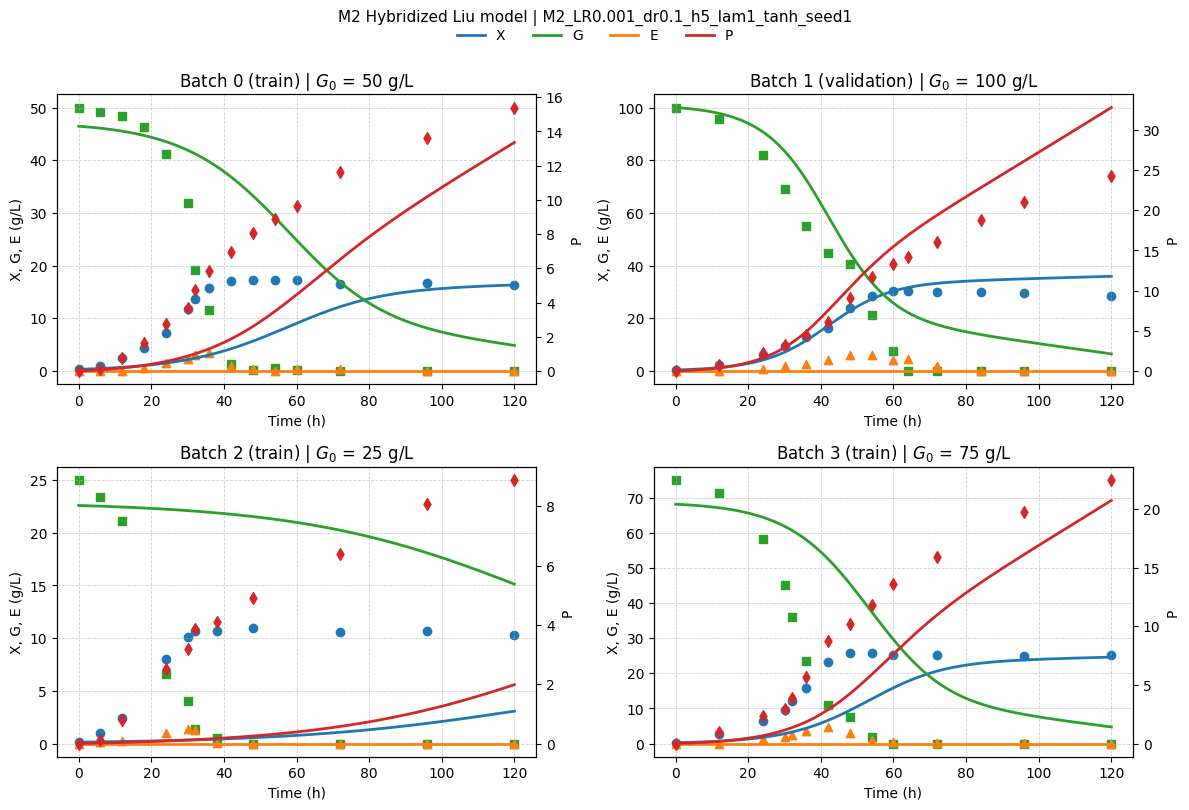

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# SCRIPT 1 of 2 — TRAIN ONE CONFIGURATION AND SAVE THE PARAMETERS
# Astaxanthin production, hybrid neural-ODE (X, G, E, P).
#
# Requires in memory (from your data cell): raw_t, raw_X, raw_G, raw_E, raw_P
#
# One training run with the configuration set below. Everything the plotting
# script needs goes into a single .pkl: the fitted parameters, the network
# architecture, the yield coefficients, the data splits AND a copy of the data,
# so plot_astaxanthin.py runs standalone -- restart the session, load the
# pickle, make figures, no retraining and no data cell needed.
#
# MODEL selects one of the two competing formulations:
#
#   M1  Proposed framework  (no reaction scheme assumed)
#         dX/dt = f1 X
#         dG/dt = f2 G X
#         dE/dt = (f3 E + g3) X
#         dP/dt = f4 P + g4 X
#       FNN: f1..f4 free, g3, g4 >= 0.  No mechanistic parameters.
#
#   M2  Hybridized Liu & Wu  (G->X, E->X, G->E ; P by Luedeking-Piret)
#         dX/dt = (rG + rE - kd) X
#         dG/dt = -(rG/Y_XG + rF/Y_EG) X
#         dE/dt = (rF - rE/Y_XE) X
#         dP/dt = alpha dX/dt + beta X
#       FNN: rG, rE, rF >= 0.  Fitted: kd, alpha, beta.
# ============================================================
import importlib.util, subprocess, sys


def _install_dependencies():
    def _has_gpu():
        try:
            return subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0
        except FileNotFoundError:
            return False
    jax_pkg = "jax[cuda12]" if _has_gpu() else "jax"
    print(f"Installing {jax_pkg}, diffrax and optax (first run only)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U",
                           jax_pkg, "diffrax", "optax"])


if importlib.util.find_spec("diffrax") is None:
    _install_dependencies()

import os, time, pickle
import numpy as np

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _show_fig(fig):
    """Inline display in Colab regardless of the backend."""
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        pass


import jax
import jax.numpy as jnp

try:
    import diffrax
    import optax
except ImportError:
    _install_dependencies()
    raise SystemExit(
        "\nDependencies reinstalled. Restart the session "
        "(Runtime -> Restart session) and run this cell again.")

print(f"jax {jax.__version__} | diffrax {diffrax.__version__} | optax {optax.__version__}")
print(f"Backend: {jax.default_backend()}")

# ========================================================
# 0. CONFIGURATION  <<<< EDIT HERE >>>>
# ========================================================
MODEL       = "M2"            # "M1" or "M2"

LR          = 1e-3
DROPOUT     = 0.1             # dropout rate used DURING TRAINING
HIDDEN      = [5]             # hidden layer sizes
LAMBDA_IC   = 1.0
ACTIVATION  = "tanh"          # "tanh", "relu" or "softplus" (hidden layers)
SEED        = 1

NUM_EPOCHS  = 8000
TRAIN_MODE  = "batch"         # "batch" (minibatch per experiment) or "global"

# --- data splits ---
# Liu & Wu batches. With the usual ordering the initial glucose concentrations
# are 50, 75, 25 and 100 g/L, so the default trains on 50/25/100 and validates
# on 75, i.e. the interior condition, exactly as in the manuscript.
train_idxs = [0, 2, 3]
valid_idxs = [1]
test_idxs  = []

# --- mass-balance coefficients (M2 only) ---
# Y_EG is the ethanol yield on glucose from C6H12O6 -> 2 C2H5OH + 2 CO2; it is
# the only coefficient with a stoichiometric basis and is never fitted.
# Y_XG and Y_XE are measured directly on the training batches, as in
# Liu & Wu. Set YIELDS_OVERRIDE to bypass, e.g. {"Y_XG": 0.372, "Y_XE": 0.324}.
Y_EG_STOICH = 0.511
YIELDS_OVERRIDE = None
MECH_INIT = {"k_d": 0.00114, "alpha": 0.342, "beta": 0.00698}

# --- solver ---
ODE_RTOL = 1e-6
ODE_ATOL = 1e-7
ODE_MAX_STEPS = 4096

# --- zero-field pretraining ---
CALIB_STEPS = 1000
CALIB_LR = 1e-3

DIVERGENCE_THRESHOLD = 1e6
EPS = 1.0e-8

# --- output ---
OUTDIR = "astaxanthin_run"
os.makedirs(OUTDIR, exist_ok=True)
RUN_NAME = (f"{MODEL}_LR{LR:g}_dr{DROPOUT:g}_h{'-'.join(map(str, HIDDEN))}"
            f"_lam{LAMBDA_IC:g}_{ACTIVATION}_seed{SEED}")
PKL_PATH = os.path.join(OUTDIR, f"model_{RUN_NAME}.pkl")

QUICK_PLOT = True             # deterministic trajectory check at the end

# ========================================================
# 1. MODEL REGISTRY
# ========================================================
MODEL_SPECS = {
    "M1": dict(label="M1 Proposed framework", n_outputs=6,
               output_names=("f1", "f2", "f3", "f4", "g3", "g4"),
               mech_names=(), fixed_yields=()),
    "M2": dict(label="M2 Hybridized Liu model", n_outputs=3,
               output_names=("r_G", "r_E", "r_F"),
               mech_names=("k_d", "alpha", "beta"),
               fixed_yields=("Y_XG", "Y_XE", "Y_EG")),
}
if MODEL not in MODEL_SPECS:
    raise ValueError(f"MODEL must be one of {list(MODEL_SPECS)}")
SPEC = MODEL_SPECS[MODEL]

# ========================================================
# 2. DATA
# ========================================================
DATA_t = [np.asarray(a, float) for a in raw_t]          # noqa: F821
DATA_X = [np.asarray(a, float) for a in raw_X]          # noqa: F821
DATA_G = [np.asarray(a, float) for a in raw_G]          # noqa: F821
DATA_E = [np.asarray(a, float) for a in raw_E]          # noqa: F821
DATA_P = [np.asarray(a, float) for a in raw_P]          # noqa: F821

t_batches = [jax.device_put(jnp.array(a)) for a in DATA_t]
X_batches = [jax.device_put(jnp.array(a)) for a in DATA_X]
G_batches = [jax.device_put(jnp.array(a)) for a in DATA_G]
E_batches = [jax.device_put(jnp.array(a)) for a in DATA_E]
P_batches = [jax.device_put(jnp.array(a)) for a in DATA_P]


def _subset(idxs):
    return ([t_batches[i] for i in idxs], [X_batches[i] for i in idxs],
            [G_batches[i] for i in idxs], [E_batches[i] for i in idxs],
            [P_batches[i] for i in idxs])


t_train, X_train, G_train, E_train, P_train = _subset(train_idxs)
t_valid, X_valid, G_valid, E_valid, P_valid = _subset(valid_idxs)
t_test,  X_test,  G_test,  E_test,  P_test  = _subset(test_idxs)

N_STATES = 4
N_OUTPUTS = SPEC["n_outputs"]
STATE_NAMES = ("X", "G", "E", "P")
LAYER_SIZES = [N_STATES] + list(HIDDEN) + [N_OUTPUTS]
N_OBS_TRAIN = int(sum(len(DATA_t[i]) for i in train_idxs) * N_STATES)


# ========================================================
# 3. YIELD COEFFICIENTS, MEASURED ON THE TRAINING BATCHES
# ========================================================
def compute_yields(verbose=True):
    """Following Liu & Wu (2008): Y_X/G and Y_X/E are calculated directly from
    the experimental data, and Y_E/G comes from the stoichiometry.

        Y_XG : glucose phase, t = 0 to the ethanol peak.  dX / (-dG)
        Y_XE : diauxic phase, glucose exhausted.          dX / (-dE)
    """
    if YIELDS_OVERRIDE:
        out = dict(Y_EG=Y_EG_STOICH)
        out.update(YIELDS_OVERRIDE)
        if verbose:
            print(f"Yields overridden by hand: {out}")
        return out

    yxg, yxe, rows = [], [], []
    for i in train_idxs:
        X, G, E = DATA_X[i], DATA_G[i], DATA_E[i]
        peak = int(np.argmax(E))
        g_thresh = 0.05 * max(G[0], EPS)

        a = np.nan
        if peak >= 1:
            dG, dX = G[0] - G[peak], X[peak] - X[0]
            if dG > 1e-6 and dX > 0:
                a = dX / dG
        if np.isfinite(a) and 0.0 < a < 1.0:
            yxg.append(a)

        mask = np.zeros_like(E, dtype=bool)
        mask[peak:] = True
        mask &= (G < g_thresh)
        idx = np.where(mask)[0]
        b = np.nan
        if idx.size >= 2:
            i0, i1 = idx[0], idx[-1]
            dE, dX = E[i0] - E[i1], X[i1] - X[i0]
            if dE > 1e-6 and dX > 0:
                b = dX / dE
        if np.isfinite(b):
            yxe.append(b)

        rows.append((i, G[0], E[peak], a, b))

    Y_XG = float(np.mean(yxg)) if yxg else 0.372
    Y_XE = float(np.mean(yxe)) if yxe else 0.324

    if verbose:
        print("\nYield coefficients measured on the TRAINING batches")
        print(f"{'batch':>6} {'G0':>7} {'E_peak':>8} {'Y_XG':>9} {'Y_XE':>9}")
        f = lambda v: f"{v:9.4f}" if np.isfinite(v) else f"{'--':>9}"
        for i, g0, ep, a, b in rows:
            print(f"{i:>6} {g0:>7.1f} {ep:>8.2f} {f(a)} {f(b)}")
        print(f"  mean Y_XG = {Y_XG:.4f}   (Liu & Wu report 0.372)")
        print(f"  mean Y_XE = {Y_XE:.4f}   (Liu & Wu report 0.324)")
        print(f"  Y_EG      = {Y_EG_STOICH:.4f}   (stoichiometric, never fitted)")

    return dict(Y_EG=Y_EG_STOICH, Y_XG=Y_XG, Y_XE=Y_XE)


YIELDS = compute_yields()

print(f"\nModel         : {SPEC['label']}")
print(f"Configuration : {RUN_NAME}")
print(f"Splits        : train={train_idxs} valid={valid_idxs} test={test_idxs}")
print(f"Architecture  : {'-'.join(map(str, LAYER_SIZES))}")
print(f"Network outputs: {', '.join(SPEC['output_names'])}")
print(f"Fitted mech.  : {', '.join(SPEC['mech_names']) or 'none'}")
print(f"Training obs  : {N_OBS_TRAIN}\n")

# ========================================================
# 4. NETWORK AND MODEL
# ========================================================
HIDDEN_ACTIVATIONS = {"tanh": jnp.tanh, "relu": jax.nn.relu,
                      "softplus": jax.nn.softplus}


def init_net_params(rng_key, layer_sizes):
    params = {}
    keys = jax.random.split(rng_key, 2 * (len(layer_sizes) - 1))
    k = 0
    for i in range(len(layer_sizes) - 1):
        n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
        params[f"W{i}"] = jax.random.uniform(keys[k], (n_out, n_in), minval=-0.1, maxval=0.1)
        params[f"b{i}"] = jax.random.uniform(keys[k + 1], (n_out,), minval=-0.1, maxval=0.1)
        k += 2
    return params


def sample_hidden_masks(net_params, rate, rng):
    if rate is None or rate <= 0.0:
        return None
    keep = 1.0 - rate
    masks = []
    num_layers = len(net_params) // 2
    for i in range(num_layers - 1):
        size = net_params[f"b{i}"].shape
        rng, ki = jax.random.split(rng)
        masks.append(jax.random.bernoulli(ki, p=keep, shape=size).astype(jnp.float32) / keep)
    return masks


def neural_network(net_params, y, *, train=False, masks=None, activation="tanh"):
    phi = HIDDEN_ACTIVATIONS[activation]
    a = y
    num_layers = net_params.__len__() // 2
    for i in range(num_layers):
        W, b = net_params[f"W{i}"], net_params[f"b{i}"]
        z = W @ a + b
        if i < num_layers - 1:
            a = phi(z)
            if train and (masks is not None):
                a = a * masks[i]
        else:
            a = z
    return a


def _inv_softplus(y):
    return float(np.log(np.expm1(max(float(y), 1e-8))))


def init_mech_params():
    return {f"raw_{k}": jnp.array(_inv_softplus(MECH_INIT[k]))
            for k in SPEC["mech_names"]}


def mech_values(mech_params):
    return {k: jax.nn.softplus(mech_params[f"raw_{k}"])
            for k in SPEC["mech_names"]}


def model_jax(net_params, mech_params, y, t, *, train=False, masks=None,
              activation="tanh"):
    X, G, E, P = y
    out = neural_network(net_params, jnp.array([X, G, E, P]),
                         train=train, masks=masks, activation=activation)

    if MODEL == "M1":
        f1, f2, f3, f4, g3, g4 = out
        g3c, g4c = jax.nn.relu(g3), jax.nn.relu(g4)
        return jnp.stack([f1 * X, f2 * G * X, (f3 * E + g3c) * X,
                          f4 * P + g4c * X])

    if MODEL == "M2":
        rG, rE, rF = jax.nn.relu(out)
        mv = mech_values(mech_params)
        k_d, alpha, beta = mv["k_d"], mv["alpha"], mv["beta"]
        growth = rG + rE - k_d
        return jnp.stack([
            growth * X,
            -(rG / YIELDS["Y_XG"] + rF / YIELDS["Y_EG"]) * X,
            (rF - rE / YIELDS["Y_XE"]) * X,
            (alpha * growth + beta) * X,
        ])

    raise ValueError(f"unknown model '{MODEL}'")


def predict(net_params, mech_params, t_array, X0, G0, *, E0=0.0, P0=0.0,
            train=False, masks=None, activation="tanh"):
    def rhs(t, y, args):
        return model_jax(net_params, mech_params, y, t, train=train,
                         masks=masks, activation=activation)
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(rhs), diffrax.Tsit5(),
        t0=t_array[0], t1=t_array[-1], dt0=None,
        y0=jnp.array([X0, G0, E0, P0]),
        saveat=diffrax.SaveAt(ts=t_array),
        stepsize_controller=diffrax.PIDController(rtol=ODE_RTOL, atol=ODE_ATOL),
        max_steps=ODE_MAX_STEPS,
        adjoint=diffrax.RecursiveCheckpointAdjoint(),
        throw=False,
    )
    ys = sol.ys
    return ys[:, 0], ys[:, 1], ys[:, 2], ys[:, 3]


predict = jax.jit(predict, static_argnames=("train", "activation"))


# ========================================================
# 5. INITIAL CONDITIONS AND LOSSES
# ========================================================
def init_ic_offset_params():
    n = len(X_train)
    X0 = jnp.array([float(np.array(X_train[i])[0]) for i in range(n)])
    G0 = jnp.array([float(np.array(G_train[i])[0]) for i in range(n)])
    return ({"alpha_X": jnp.zeros_like(X0), "alpha_G": jnp.zeros_like(G0)},
            {"X0": X0, "G0": G0})


def ic_for_train_batch(params, idx):
    X0 = params["ic_meas"]["X0"][idx] * jnp.exp(params["ic_alpha"]["alpha_X"][idx])
    G0 = params["ic_meas"]["G0"][idx] * jnp.exp(params["ic_alpha"]["alpha_G"][idx])
    return X0, G0, jnp.array(0.0), jnp.array(0.0)


def safe_rel(pred, obs):
    return (pred - obs) / jnp.maximum(jnp.mean(jnp.abs(obs)), EPS)


def _mse4(Xp, Gp, Ep, Pp, Xo, Go, Eo, Po):
    return (jnp.mean(safe_rel(Xp, Xo) ** 2) + jnp.mean(safe_rel(Gp, Go) ** 2) +
            jnp.mean(safe_rel(Ep, Eo) ** 2) + jnp.mean(safe_rel(Pp, Po) ** 2))


def batch_loss_train(params, idx, rng):
    X0, G0, E0, P0 = ic_for_train_batch(params, idx)
    masks = sample_hidden_masks(params["net"], DROPOUT, rng)
    Xp, Gp, Ep, Pp = predict(params["net"], params["mech"], t_train[idx], X0, G0,
                             E0=E0, P0=P0, train=True, masks=masks,
                             activation=ACTIVATION)
    data_loss = _mse4(Xp, Gp, Ep, Pp,
                      X_train[idx], G_train[idx], E_train[idx], P_train[idx])
    reg = LAMBDA_IC * (params["ic_alpha"]["alpha_X"][idx] ** 2 +
                       params["ic_alpha"]["alpha_G"][idx] ** 2)
    return data_loss + reg


batch_loss_train_jit = jax.jit(batch_loss_train, static_argnums=(1,))


def global_train_loss(params, rng_key):
    total = 0.0
    for idx in range(len(t_train)):
        total += batch_loss_train(params, idx, jax.random.fold_in(rng_key, idx))
    return total / len(t_train)


def batch_loss_train_eval(params, idx):
    X0, G0, E0, P0 = ic_for_train_batch(params, idx)
    Xp, Gp, Ep, Pp = predict(params["net"], params["mech"], t_train[idx], X0, G0,
                             E0=E0, P0=P0, train=False, masks=None,
                             activation=ACTIVATION)
    return _mse4(Xp, Gp, Ep, Pp,
                 X_train[idx], G_train[idx], E_train[idx], P_train[idx])


batch_loss_train_eval_jit = jax.jit(batch_loss_train_eval, static_argnums=(1,))


def loss_heldout(net, mech, t_o, X_o, G_o, E_o, P_o):
    Xp, Gp, Ep, Pp = predict(net, mech, t_o, X_o[0], G_o[0], E0=0.0, P0=0.0,
                             train=False, masks=None, activation=ACTIVATION)
    return _mse4(Xp, Gp, Ep, Pp, X_o, G_o, E_o, P_o)


loss_heldout_jit = jax.jit(loss_heldout)


# ========================================================
# 6. ZERO-FIELD PRETRAINING
# ========================================================
def calib_loss(net_params, points):
    target = jnp.zeros(N_OUTPUTS)

    def per_point(y):
        return jnp.mean((neural_network(net_params, y, train=False,
                                        activation=ACTIVATION) - target) ** 2)
    return jnp.mean(jax.vmap(per_point)(points))


def calibrate(net_params, points, steps=CALIB_STEPS, lr=CALIB_LR):
    """Drive the network outputs to zero so the vector field starts neutral.
    For M2 a residual -k_d X decay term remains, which is small and
    physically meaningful."""
    optc = optax.adam(lr)
    opt_state = optc.init(net_params)

    @jax.jit
    def step(p, s):
        loss, grads = jax.value_and_grad(calib_loss)(p, points)
        updates, s = optc.update(grads, s, p)
        return optax.apply_updates(p, updates), s, loss

    p = net_params
    for _ in range(steps):
        p, opt_state, _ = step(p, opt_state)
    return p


_calib_points = jnp.array([[x, g, e, p]
                           for i in train_idxs
                           for x, g, e, p in zip(DATA_X[i], DATA_G[i],
                                                 DATA_E[i], DATA_P[i])])

# ========================================================
# 7. TRAINING
# ========================================================
rng_master = jax.random.PRNGKey(SEED)
np.random.seed(SEED)
t0_cpu, t0_wall = time.process_time(), time.perf_counter()

net_params = init_net_params(jax.random.fold_in(rng_master, 0), LAYER_SIZES)
net_params = calibrate(net_params, _calib_points)

ic_alpha, ic_meas = init_ic_offset_params()
params = {"net": net_params, "mech": init_mech_params(),
          "ic_alpha": ic_alpha, "ic_meas": ic_meas}

opt = optax.adam(LR)
opt_state = opt.init(params)


def eval_avg_train_loss(p):
    v = [float(batch_loss_train_eval_jit(p, i)) for i in range(len(t_train))]
    return float(np.mean(v)) if v else np.nan


def eval_split(net, mech, T, Xs, Gs, Es, Ps):
    v = [float(loss_heldout_jit(net, mech, T[i], Xs[i], Gs[i], Es[i], Ps[i]))
         for i in range(len(T))]
    return (float(np.mean(v)) if v else np.nan), v


def _blown_up(tr, va):
    return (not (np.isfinite(tr) and np.isfinite(va))
            or tr > DIVERGENCE_THRESHOLD or va > DIVERGENCE_THRESHOLD)


train_history, valid_history = [], []
best_val, best_epoch, best_params = np.inf, None, None
diverged = False

if TRAIN_MODE == "batch":
    def train_step(params, opt_state, idx, rng):
        grads = jax.grad(batch_loss_train_jit)(params, idx, rng)
        updates, opt_state = opt.update(grads, opt_state, params)
        return optax.apply_updates(params, updates), opt_state
    train_step = jax.jit(train_step, static_argnums=(2,))

    for epoch in range(1, NUM_EPOCHS + 1):
        epoch_key = jax.random.fold_in(rng_master, epoch)
        perm = np.array(jax.random.permutation(epoch_key, len(t_train)))
        for idx in perm:
            params, opt_state = train_step(params, opt_state, int(idx),
                                           jax.random.fold_in(epoch_key, int(idx)))
        tr = eval_avg_train_loss(params)
        va, _ = eval_split(params["net"], params["mech"],
                           t_valid, X_valid, G_valid, E_valid, P_valid)
        train_history.append(tr); valid_history.append(va)
        if _blown_up(tr, va):
            diverged = True
            print(f"  ep {epoch}: DIVERGED -> aborted")
            break
        if va < best_val:
            best_val, best_epoch = float(va), epoch
            best_params = jax.tree_util.tree_map(lambda x: np.array(x), params)
        if epoch % 400 == 0:
            print(f"  ep {epoch}: train={tr:.6f}, valid={va:.6f}")

elif TRAIN_MODE == "global":
    # jax.grad deliberately NOT jitted here (TPU compiler issue).
    for epoch in range(1, NUM_EPOCHS + 1):
        epoch_key = jax.random.fold_in(rng_master, epoch)
        grads = jax.grad(global_train_loss)(params, epoch_key)
        updates, opt_state = opt.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        tr = eval_avg_train_loss(params)
        va, _ = eval_split(params["net"], params["mech"],
                           t_valid, X_valid, G_valid, E_valid, P_valid)
        train_history.append(tr); valid_history.append(va)
        if _blown_up(tr, va):
            diverged = True
            print(f"  ep {epoch}: DIVERGED -> aborted")
            break
        if va < best_val:
            best_val, best_epoch = float(va), epoch
            best_params = jax.tree_util.tree_map(lambda x: np.array(x), params)
        if epoch % 400 == 0:
            print(f"  ep {epoch}: train={tr:.6f}, valid={va:.6f}")
else:
    raise ValueError("TRAIN_MODE must be 'batch' or 'global'")

cpu_time_s = time.process_time() - t0_cpu
wall_time_s = time.perf_counter() - t0_wall

if best_params is None:
    raise SystemExit("Training produced no usable parameters (diverged immediately).")

print(f"\nDone in {wall_time_s:.0f}s wall / {cpu_time_s:.0f}s cpu"
      f"{' (DIVERGED)' if diverged else ''}")
print(f"Best validation loss: {best_val:.6e} at epoch {best_epoch}")

bnet = jax.tree_util.tree_map(jnp.asarray, best_params["net"])
bmech = jax.tree_util.tree_map(jnp.asarray, best_params["mech"])
b_alpha = jax.tree_util.tree_map(jnp.asarray, best_params["ic_alpha"])
b_meas = jax.tree_util.tree_map(jnp.asarray, best_params["ic_meas"])

mech_fitted = {}
if SPEC["mech_names"]:
    mech_fitted = {k: float(v) for k, v in mech_values(bmech).items()}
    print("Fitted mechanistic parameters: " +
          " ".join(f"{k}={v:.4g}" for k, v in mech_fitted.items()))
    print("  published by Liu & Wu:       " +
          " ".join(f"{k}={MECH_INIT[k]:.4g}" for k in mech_fitted))


# ========================================================
# 8. R^2 REPORT AND NON-NEGATIVITY CHECK
# ========================================================
def _r2(obs, pred):
    obs = np.asarray(obs, float).ravel()
    pred = np.asarray(pred, float).ravel()
    n = min(obs.size, pred.size)
    obs, pred = obs[:n], pred[:n]
    m = np.isfinite(obs) & np.isfinite(pred)
    if m.sum() < 2:
        return np.nan
    o, p = obs[m], pred[m]
    ss = float(np.sum((o - o.mean()) ** 2))
    return float(1.0 - np.sum((o - p) ** 2) / ss) if ss > 0 else np.nan


ROLE_OF = {}
for i in train_idxs:
    ROLE_OF[i] = "train"
for i in valid_idxs:
    ROLE_OF[i] = "validation"
for i in test_idxs:
    ROLE_OF[i] = "test"


def initial_condition(bidx):
    if bidx in train_idxs:
        pos = train_idxs.index(bidx)
        return (float(b_meas["X0"][pos] * jnp.exp(b_alpha["alpha_X"][pos])),
                float(b_meas["G0"][pos] * jnp.exp(b_alpha["alpha_G"][pos])))
    return float(DATA_X[bidx][0]), float(DATA_G[bidx][0])


print(f"\n{'batch':>6} {'G0':>6} {'role':>11} "
      + " ".join(f"{'R2_' + v:>9}" for v in STATE_NAMES))
r2_table, global_min = {}, {v: np.inf for v in STATE_NAMES}
for bidx in sorted(ROLE_OF):
    X0, G0 = initial_condition(bidx)
    P = predict(bnet, bmech, jnp.array(DATA_t[bidx]), X0, G0, E0=0.0, P0=0.0,
                train=False, masks=None, activation=ACTIVATION)
    r2s = [_r2(o, np.array(p)) for o, p in
           zip((DATA_X[bidx], DATA_G[bidx], DATA_E[bidx], DATA_P[bidx]), P)]
    r2_table[bidx] = r2s
    print(f"{bidx:>6} {DATA_G[bidx][0]:>6.0f} {ROLE_OF[bidx]:>11} "
          + " ".join(f"{v:>9.4f}" for v in r2s))
    # dense grid so minima are not missed between sampling times
    td = jnp.linspace(float(DATA_t[bidx].min()), float(DATA_t[bidx].max()), 400)
    dense = predict(bnet, bmech, td, X0, G0, E0=0.0, P0=0.0, train=False,
                    masks=None, activation=ACTIVATION)
    for v, arr in zip(STATE_NAMES, dense):
        a = np.asarray(arr, float)
        if np.any(np.isfinite(a)):
            global_min[v] = min(global_min[v], float(np.nanmin(a)))

print("\nMinimum concentration reached along the simulated trajectories:")
print("  " + "  ".join(f"min {v} = {global_min[v]:.3e}" for v in STATE_NAMES))
any_neg = any(np.isfinite(global_min[v]) and global_min[v] < -1e-6
              for v in STATE_NAMES)
print("  -> " + ("NEGATIVE STATES PRESENT" if any_neg else
                 "all states non-negative (solver tolerance aside)"))

# ========================================================
# 9. SAVE
# ========================================================
bundle = {
    "model": MODEL,
    "model_label": SPEC["label"],
    "output_names": SPEC["output_names"],
    "mech_names": SPEC["mech_names"],
    "params": best_params,                 # net, mech, ic_alpha, ic_meas
    "mech_fitted": mech_fitted,
    "yields": YIELDS,
    "layer_sizes": LAYER_SIZES,
    "activation": ACTIVATION,
    "dropout_train": DROPOUT,
    "config": dict(lr=LR, dropout=DROPOUT, hidden=list(HIDDEN),
                   lambda_ic=LAMBDA_IC, activation=ACTIVATION, seed=SEED,
                   num_epochs=NUM_EPOCHS, train_mode=TRAIN_MODE, model=MODEL),
    "splits": dict(train=list(train_idxs), valid=list(valid_idxs),
                   test=list(test_idxs)),
    "solver": dict(rtol=ODE_RTOL, atol=ODE_ATOL, max_steps=ODE_MAX_STEPS),
    "data": dict(t=DATA_t, X=DATA_X, G=DATA_G, E=DATA_E, P=DATA_P),
    "history": dict(train=np.asarray(train_history, float),
                    valid=np.asarray(valid_history, float)),
    "result": dict(best_val=float(best_val), best_epoch=best_epoch,
                   diverged=bool(diverged), cpu_time_s=float(cpu_time_s),
                   wall_time_s=float(wall_time_s), r2=r2_table,
                   min_states={k: float(v) for k, v in global_min.items()},
                   any_negative_state=bool(any_neg)),
    "run_name": RUN_NAME,
}

with open(PKL_PATH, "wb") as fh:
    pickle.dump(bundle, fh)

print(f"\nParameters saved to: {PKL_PATH}")
print("Use this path in the plotting script (PKL_PATH).")

# ========================================================
# 10. QUICK CHECK PLOT (deterministic, no dropout)
# ========================================================
if QUICK_PLOT:
    COL = {"X": "#1f77b4", "G": "#2ca02c", "E": "#ff7f0e", "P": "#d62728"}
    MK = {"X": "o", "G": "s", "E": "^", "P": "d"}
    idxs = sorted(ROLE_OF)
    ncols = 2 if len(idxs) > 1 else 1
    nrows = int(np.ceil(len(idxs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.8 * nrows),
                             squeeze=False)
    axes = axes.ravel()
    for k, bidx in enumerate(idxs):
        ax1 = axes[k]; ax2 = ax1.twinx()
        X0, G0 = initial_condition(bidx)
        td = jnp.linspace(float(DATA_t[bidx].min()), float(DATA_t[bidx].max()), 400)
        Xp, Gp, Ep, Pp = predict(bnet, bmech, td, X0, G0, E0=0.0, P0=0.0,
                                 train=False, masks=None, activation=ACTIVATION)
        td = np.array(td)
        ax1.plot(td, np.array(Xp), color=COL["X"], lw=2)
        ax1.plot(td, np.array(Gp), color=COL["G"], lw=2)
        ax1.plot(td, np.array(Ep), color=COL["E"], lw=2)
        ax2.plot(td, np.array(Pp), color=COL["P"], lw=2)
        ax1.scatter(DATA_t[bidx], DATA_X[bidx], marker=MK["X"], color=COL["X"])
        ax1.scatter(DATA_t[bidx], DATA_G[bidx], marker=MK["G"], color=COL["G"])
        ax1.scatter(DATA_t[bidx], DATA_E[bidx], marker=MK["E"], color=COL["E"])
        ax2.scatter(DATA_t[bidx], DATA_P[bidx], marker=MK["P"], color=COL["P"])
        ax1.set_title(f"Batch {bidx} ({ROLE_OF[bidx]}) | "
                      f"$G_0$ = {DATA_G[bidx][0]:.0f} g/L")
        ax1.set_xlabel("Time (h)"); ax1.set_ylabel("X, G, E (g/L)")
        ax2.set_ylabel("P")
        ax1.grid(True, ls="--", lw=0.6, alpha=0.6)
    for j in range(len(idxs), len(axes)):
        axes[j].axis("off")
    handles = [Line2D([0], [0], color=COL[v], lw=2, label=v) for v in STATE_NAMES]
    fig.tight_layout()
    fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
               bbox_to_anchor=(0.5, 1.0))
    fig.suptitle(f"{SPEC['label']} | {RUN_NAME}", y=1.06, fontsize=11)
    fig.savefig(os.path.join(OUTDIR, f"quickcheck_{RUN_NAME}.png"), dpi=150,
                bbox_inches="tight")
    _show_fig(fig)
    plt.close(fig)

try:
    from google.colab import files
    files.download(PKL_PATH)
except Exception:
    pass

The following code produces the **figures and the R² table from an already trained
model**, without retraining anything. It loads the `.pkl` written by the training script
— which carries the fitted parameters, the architecture, the yields, the splits and a
copy of the data — so it runs standalone: restart the session, point `PKL_PATH` at the
pickle and run. It rebuilds the same right-hand side used in training, for M1 or for M2,
and produces three things.

**Figure 1 — trajectories with uncertainty bands.** One panel per batch, labelled by its
role, with $X$, $G$ and $E$ on the left axis and $P$ on the right. The bands come from
**Monte Carlo dropout**: dropout is kept active at prediction time and the model is
integrated `MC_SAMPLES` times, each realisation using one dropout mask held fixed along
the whole trajectory, exactly as during training, so that every sample solves a
well-defined system. The band spans the $2.5$th–$97.5$th percentiles by default. The
script also reports, per batch and per variable, the **relative width** of the band
(mean width divided by the mean observed value) and its **coverage** (fraction of
measurements falling inside it).

**Figure 2 — interpretability scatter**, evaluated deterministically with dropout off.
The network outputs are plotted at the measured data points, with the specific growth
rate on the $x$ axis, and what appears depends on the model:

- **M1:** $g_3$ vs $f_1$ and $g_4$ vs $f_1$, the specific ethanol and pigment production
  rates against the specific growth rate.
- **M2:** $r_F$ vs $r_G + r_E - k_d$ only. The astaxanthin panel is deliberately skipped,
  because in M2 the pigment follows the Luedeking–Piret correlation and plotting it
  against growth would give a straight line by construction, carrying no information.

A reference curve is fitted per panel and drawn without any legend entry or annotation;
its parameters are printed to the console instead. The form is a **hinge**
$y = \max(k(x-l),0)$ for the ethanol panel, which captures the overflow-like onset, and a
**straight line** for the pigment panel. The hinge is fitted by scanning the threshold
$l$ over the observed range and solving for $k$ in closed form on the active set, which
avoids the local minima a joint gradient fit falls into when the hinge is inactive.

**A LaTeX R² table**, one row per experiment identified by its initial glucose
concentration, with a `\midrule` at each change of role. It is computed from the
**deterministic** trajectory, so with `SHOW_MEAN = False` the table and the curve drawn
in Figure 1 refer to the same model. The script prints alongside it the standard
deviation and the RMSE of each variable, which explains the negative values: $R^2$ is
normalised by each variable's own spread within its experiment, so a moderate absolute
error drives it below zero whenever a variable barely moves.

---

### 🔧 Configuration

Everything is set in the block at the top:

- **PKL_PATH:** the trained model to load. It determines the model, the architecture and
  the data, so nothing else needs to be kept in sync by hand.

- **PLOT_BATCHES / SORT_BY_ROLE:** which batches to draw and in which order. `None` takes
  every batch in the splits; `SORT_BY_ROLE` puts training first, then validation, then
  test.

- **MC_SAMPLES, MC_RATE, MC_CI, MC_SEED:** the Monte Carlo dropout settings. `MC_RATE =
  None` reuses the training rate stored in the pickle; an explicit value overrides it and
  is **required** if the model was trained without dropout, since a zero rate makes all
  samples identical and the band collapses to a line. The script warns when that happens.

- **SHOW_MEAN:** which line is drawn inside the band. `False` (default) draws the
  deterministic trajectory, keeping figure and table consistent; `True` draws the mean of
  the samples, which is a genuinely different curve, because averaging stochastic
  solutions of a nonlinear ODE does not give the deterministic one.

- **N_DENSE:** time points per trajectory; lower is faster.

- **INTERP_BATCHES / INTERP_FIT / INTERP_FIT_ON:** which batches enter the
  interpretability figure, which reference curve each panel gets (`"hinge"`, `"line"` or
  `None`) and which batches the fits use. Named selections such as `"training"`,
  `"training+validation"` or `"all"` are accepted anywhere a batch list is expected.

- **MAKE_R2_TABLE, R2_DECIMALS, R2_TABLE_BATCHES, R2_TABLE_CAPTION, R2_TABLE_LABEL:** the
  LaTeX table, written to a `.tex` file and echoed to the console ready to paste.

- **FORMATS / DOWNLOAD_FORMATS:** output formats. **PDF** is preferred over EPS: both are
  vector, but EPS has no alpha channel, so with `"eps"` in `FORMATS` the bands are drawn
  as solid pre-blended colours and overlapping bands hide one another. The script detects
  this and switches the blending automatically.

- **FIG_TRAJECTORIES / FIG_INTERP, DPI, PANEL_W, PANEL_H, NCOLS, LEGEND_NCOL:** file
  names and layout.

---

### 📦 Outputs

Written to `astaxanthin_figures/`: the two figures in every requested format and the
`.tex` file with the R² table. In Colab the files in `DOWNLOAD_FORMATS` are downloaded
automatically.

Loaded    : astaxanthin_run/model_M2_LR0.001_dr0.1_h5_lam1_tanh_seed1.pkl
Model     : M2 Hybridized Liu model
Run       : M2_LR0.001_dr0.1_h5_lam1_tanh_seed1
Arch      : 4-5-3 | activation tanh
Outputs   : r_G, r_E, r_F
Fitted    : k_d=0.001153 alpha=0.3536 beta=0.007434
Yields    : Y_EG=0.511 Y_XG=0.4138 Y_XE=0.324 Y_PX=0.8701
Splits    : train=[0, 2, 3] valid=[1] test=[]
MC dropout: 500 samples at rate 0.1 (training rate was 0.1) | 95% interval
Plotting  : batches [0, 2, 3, 1]

Simulating MC-dropout bands...


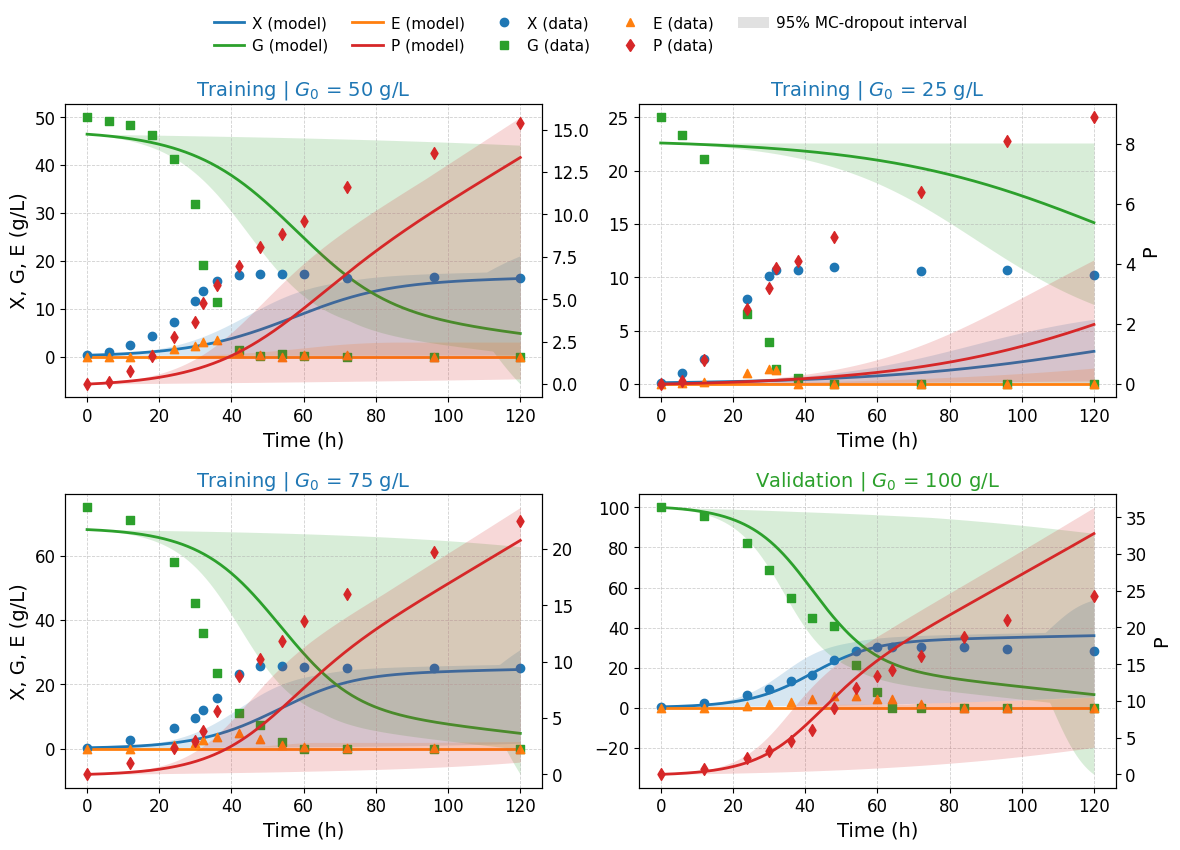


Band statistics (relative width / coverage):
      G0         set                X                G                E                P
      50    training      0.921 / 13%      1.309 / 13%      1.977 / 60%      1.087 / 13%
      25    training       0.278 / 0%       0.725 / 0%      1.347 / 55%       0.319 / 9%
      75    training      0.938 / 15%       1.562 / 8%      0.820 / 54%      1.124 / 15%
     100  validation      1.259 / 86%      1.702 / 43%      0.807 / 43%      1.558 / 93%
  rel. width = mean band width / mean observed value
  coverage   = fraction of measurements falling inside the band


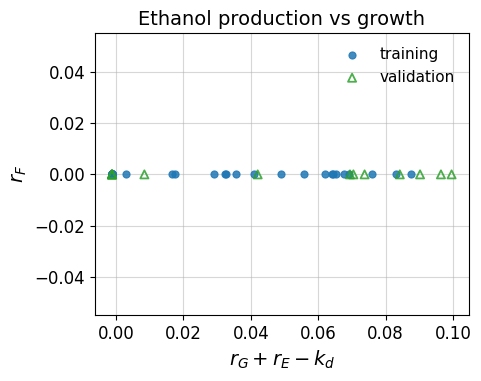


Interpretability figure: batches [0, 2, 3, 1] (training, validation)
  only the ethanol panel is shown: in M2 astaxanthin follows the
  Luedeking-Piret correlation, so plotting it against the growth
  rate would be a straight line by construction.
  no reference curve could be fitted (not enough active points?)

LaTeX R^2 table (copy-paste ready)
\begin{table}[h!]
\centering
\caption{Determination coefficients ($R^2$) comparing model simulations with the experimental data of \cite{liu2008modeling} for biomass ($X$), glucose ($G$), ethanol ($E$) and astaxanthin ($P$). Each experiment is identified by its initial glucose concentration $G_0$.}
\begin{tabular}{llrrrr}
\toprule
\textbf{Experiment} & \textbf{Set} & $\boldsymbol{X}$ & $\boldsymbol{G}$ & $\boldsymbol{E}$ & $\boldsymbol{P}$ \\
\midrule
$G_0 = 50$ g/L & Training & $-0.49$ & 0.16 & $-0.58$ & 0.40 \\
$G_0 = 25$ g/L & Training & $-2.72$ & $-1.71$ & $-0.47$ & $-1.16$ \\
$G_0 = 75$ g/L & Training & 0.03 & 0.20 & $-0.87$ & 0.67 \\
\m

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  - astaxanthin_figures/figure6.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# SCRIPT 2 of 2 — FIGURES FROM A SAVED MODEL (no retraining)
# Astaxanthin production, hybrid neural-ODE (X, G, E, P).
#
# Loads the .pkl written by train_astaxanthin.py and produces:
#
#   FIGURE 1 — trajectories with MC-dropout uncertainty bands, one panel per
#              selected batch, labelled with its role. X, G, E on the left
#              axis, P on the right axis.
#
#   FIGURE 2 — interpretability scatter, evaluated WITHOUT dropout. What is
#              plotted depends on the model:
#                M1 : g3 vs f1 and g4 vs f1   (specific ethanol and pigment
#                     production rates against the specific growth rate)
#                M2 : r_F vs net growth rate  (astaxanthin follows
#                     Luedeking-Piret, so plotting it against growth would be a
#                     straight line by construction and is skipped)
#                M3 : r_F and r_P vs net growth rate
#
#   A LaTeX R^2 table, one row per experiment.
#
# The pickle carries the data, the yields and the fitted mechanistic
# parameters, so this script runs standalone.
# ============================================================
import os, pickle
import numpy as np

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import jax
import jax.numpy as jnp
import diffrax


def _show_fig(fig):
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        pass


# ========================================================
# 0. WHAT TO PLOT  <<<< EDIT HERE >>>>
# ========================================================
PKL_PATH = "astaxanthin_run/model_M2_LR0.001_dr0.1_h5_lam1_tanh_seed1.pkl"

# --- which batches, and in which order ---
# None = every batch in the splits. Otherwise a list of batch indices.
PLOT_BATCHES = None
SORT_BY_ROLE = True         # training first, then validation, then test

# --- Monte Carlo dropout ---
MC_SAMPLES = 500        # stochastic forward simulations per batch
MC_RATE = None          # None = reuse the training dropout rate from the
                        # pickle. Set a float to override (REQUIRED if the
                        # model was trained with dropout = 0, since a zero rate
                        # gives no variability). Report the choice in the paper.
MC_CI = 95.0            # interval width in percent (95 -> 2.5/97.5 percentiles)
MC_SEED = 0             # change to resample the bands
BAND_ALPHA = 0.18
SHOW_MEAN = False       # Which line is drawn inside the band.
                        # False (default) = the DETERMINISTIC trajectory, which
                        #   is the model the R^2 table refers to, so figure and
                        #   table stay consistent.
                        # True = the mean of the MC samples. That is a DIFFERENT
                        #   curve: averaging stochastic solutions of a nonlinear
                        #   ODE does not give the deterministic solution.
N_DENSE = 400           # time points per trajectory (lower = faster)

# --- interpretability figure ---
INTERP_BATCHES = "all"      # "training", "validation", "test",
                            # "training+validation", "all", None (= PLOT_BATCHES)
                            # or an explicit list
INTERP_FIGSIZE = (10.0, 4.0)    # widened automatically for two panels
INTERP_STYLE = {
    "training":   dict(color="#1f77b4", marker="o", filled=True,  s=26),
    "validation": dict(color="#2ca02c", marker="^", filled=False, s=34),
    "test":       dict(color="#d62728", marker="s", filled=False, s=30),
}
INTERP_LEGEND = True
# A reference curve is fitted per panel and drawn, but nothing on the figure
# identifies it -- no legend entry, no annotation. The parameters go to the
# console. The functional form differs by panel:
#   "hinge"  y = max(k*(x - l), 0)   the overflow-like onset of ethanol
#   "line"   y = a*x + b             astaxanthin grows roughly linearly with
#                                    the specific growth rate
#   None     no curve on that panel
INTERP_FIT = {"E": "hinge", "P": "line"}
INTERP_FIT_ON = "training"      # which points the fits use
INTERP_FIT_COLOR = "#000000"
INTERP_FIT_LW = 1.0

# --- LaTeX R^2 table ---
MAKE_R2_TABLE = True
R2_DECIMALS = 2
R2_TABLE_BATCHES = "all"
R2_ID_HEADER = r"\textbf{Experiment}"
R2_ROLE_COLUMN = True
R2_TABLE_LABEL = "tab:r2_astaxanthin"
R2_TABLE_CAPTION = (
    "Determination coefficients ($R^2$) comparing model simulations with the "
    "experimental data of \\cite{liu2008modeling} for biomass ($X$), glucose "
    "($G$), ethanol ($E$) and astaxanthin ($P$). Each experiment is identified "
    "by its initial glucose concentration $G_0$.")

# --- output ---
OUTDIR = "astaxanthin_figures"
# PDF is vector AND supports transparency, so overlapping uncertainty bands
# blend properly. Elsevier lists PDF alongside EPS for vector artwork.
# EPS has no alpha channel: with "eps" in FORMATS the bands are drawn as solid
# pre-blended colours, which is safe but makes overlapping bands hide one
# another. Prefer "pdf" unless EPS is mandatory.
FORMATS = ("png", "pdf")
DOWNLOAD_FORMATS = ("pdf",)
FIG_TRAJECTORIES = "figure5"    # trajectories with MC-dropout bands
FIG_INTERP = "figure6"          # interpretability scatter
DPI = 150
PANEL_W, PANEL_H = 6.0, 4.0
NCOLS = 2
LEGEND_NCOL = 5             # 9 legend entries (4 lines, 4 markers, 1 patch)
DOWNLOAD = True

os.makedirs(OUTDIR, exist_ok=True)

ALPHA_OK = "eps" not in [f.lower() for f in FORMATS]


def _blend(color, alpha, bg="white"):
    """Blend a colour towards the background, for the EPS fallback."""
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(color))
    b = np.array(mcolors.to_rgb(bg))
    return tuple(alpha * c + (1.0 - alpha) * b)


def band_kwargs(color):
    if ALPHA_OK:
        return dict(color=color, alpha=BAND_ALPHA)
    return dict(color=_blend(color, BAND_ALPHA))


def point_kwargs(color, filled):
    if filled:
        face = color if ALPHA_OK else _blend(color, 0.8)
        d = dict(facecolors=face, edgecolors=color, linewidths=0.8)
    else:
        d = dict(facecolors="none", edgecolors=color, linewidths=1.3)
    if ALPHA_OK:
        d["alpha"] = 0.85
    return d


# ========================================================
# 1. LOAD THE TRAINED MODEL
# ========================================================
with open(PKL_PATH, "rb") as fh:
    B = pickle.load(fh)

MODEL = B["model"]
MODEL_LABEL = B["model_label"]
OUTPUT_NAMES = B["output_names"]
MECH_NAMES = B["mech_names"]
params = B["params"]
YIELDS = B["yields"]
LAYER_SIZES = B["layer_sizes"]
ACTIVATION = B["activation"]
DROPOUT_TRAIN = B["dropout_train"]
SPLITS = B["splits"]
SOLVER = B["solver"]
RUN_NAME = B.get("run_name", "model")

DATA_t, DATA_X = B["data"]["t"], B["data"]["X"]
DATA_G, DATA_E, DATA_P = B["data"]["G"], B["data"]["E"], B["data"]["P"]

train_idxs, valid_idxs, test_idxs = SPLITS["train"], SPLITS["valid"], SPLITS["test"]

ROLE_OF = {}
for i in train_idxs:
    ROLE_OF[i] = "training"
for i in valid_idxs:
    ROLE_OF[i] = "validation"
for i in test_idxs:
    ROLE_OF[i] = "test"
ROLE_ORDER = {"training": 0, "validation": 1, "test": 2}

STATE_NAMES = ("X", "G", "E", "P")
COL = {"X": "#1f77b4", "G": "#2ca02c", "E": "#ff7f0e", "P": "#d62728"}
MARK = {"X": "o", "G": "s", "E": "^", "P": "d"}
ROLE_COL = {"training": "#1f77b4", "validation": "#2ca02c", "test": "#d62728"}

_PLOT_RC = {"font.size": 13, "axes.titlesize": 14, "axes.labelsize": 14,
            "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11}

mc_rate = MC_RATE if MC_RATE is not None else DROPOUT_TRAIN

print(f"Loaded    : {PKL_PATH}")
print(f"Model     : {MODEL_LABEL}")
print(f"Run       : {RUN_NAME}")
print(f"Arch      : {'-'.join(map(str, LAYER_SIZES))} | activation {ACTIVATION}")
print(f"Outputs   : {', '.join(OUTPUT_NAMES)}")
if MECH_NAMES:
    print(f"Fitted    : " + " ".join(f"{k}={v:.4g}"
                                     for k, v in B["mech_fitted"].items()))
    print(f"Yields    : " + " ".join(f"{k}={v:.4g}" for k, v in YIELDS.items()))
print(f"Splits    : train={train_idxs} valid={valid_idxs} test={test_idxs}")
print(f"MC dropout: {MC_SAMPLES} samples at rate {mc_rate:g} "
      f"(training rate was {DROPOUT_TRAIN:g}) | {MC_CI:g}% interval")
if mc_rate <= 0.0:
    print("\nWARNING: the MC rate is zero, so all sampled trajectories are\n"
          "identical and the bands collapse to a line. Set MC_RATE > 0.\n")

# ========================================================
# 2. MODEL (identical to the training script)
# ========================================================
HIDDEN_ACTIVATIONS = {"tanh": jnp.tanh, "relu": jax.nn.relu,
                      "softplus": jax.nn.softplus}


def sample_hidden_masks(net_params, rate, rng):
    if rate is None or rate <= 0.0:
        return None
    keep = 1.0 - rate
    masks = []
    num_layers = len(net_params) // 2
    for i in range(num_layers - 1):
        size = net_params[f"b{i}"].shape
        rng, ki = jax.random.split(rng)
        masks.append(jax.random.bernoulli(ki, p=keep, shape=size).astype(jnp.float32) / keep)
    return masks


def neural_network(net_params, y, *, train=False, masks=None, activation="tanh"):
    phi = HIDDEN_ACTIVATIONS[activation]
    a = y
    num_layers = len(net_params) // 2
    for i in range(num_layers):
        W, b = net_params[f"W{i}"], net_params[f"b{i}"]
        z = W @ a + b
        if i < num_layers - 1:
            a = phi(z)
            if train and (masks is not None):
                a = a * masks[i]
        else:
            a = z
    return a


def mech_values(mech_params):
    return {k: jax.nn.softplus(mech_params[f"raw_{k}"]) for k in MECH_NAMES}


def model_jax(net_params, mech_params, y, t, *, train=False, masks=None,
              activation="tanh"):
    X, G, E, P = y
    out = neural_network(net_params, jnp.array([X, G, E, P]),
                         train=train, masks=masks, activation=activation)

    if MODEL == "M1":
        f1, f2, f3, f4, g3, g4 = out
        g3c, g4c = jax.nn.relu(g3), jax.nn.relu(g4)
        return jnp.stack([f1 * X, f2 * G * X, (f3 * E + g3c) * X,
                          f4 * P + g4c * X])

    if MODEL == "M2":
        rG, rE, rF = jax.nn.relu(out)
        mv = mech_values(mech_params)
        k_d, alpha, beta = mv["k_d"], mv["alpha"], mv["beta"]
        growth = rG + rE - k_d
        return jnp.stack([
            growth * X,
            -(rG / YIELDS["Y_XG"] + rF / YIELDS["Y_EG"]) * X,
            (rF - rE / YIELDS["Y_XE"]) * X,
            (alpha * growth + beta) * X,
        ])

    rG, rE, rF, rP = jax.nn.relu(out)
    k_d = mech_values(mech_params)["k_d"]
    return jnp.stack([
        (rG + rE - rP / YIELDS["Y_PX"] - k_d) * X,
        -(rG / YIELDS["Y_XG"] + rF / YIELDS["Y_EG"]) * X,
        (rF - rE / YIELDS["Y_XE"]) * X,
        rP * X,
    ])


def predict(net_params, mech_params, t_array, X0, G0, *, E0=0.0, P0=0.0,
            train=False, masks=None, activation="tanh"):
    def rhs(t, y, args):
        return model_jax(net_params, mech_params, y, t, train=train,
                         masks=masks, activation=activation)
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(rhs), diffrax.Tsit5(),
        t0=t_array[0], t1=t_array[-1], dt0=None,
        y0=jnp.array([X0, G0, E0, P0]),
        saveat=diffrax.SaveAt(ts=t_array),
        stepsize_controller=diffrax.PIDController(rtol=SOLVER["rtol"],
                                                 atol=SOLVER["atol"]),
        max_steps=SOLVER["max_steps"],
        adjoint=diffrax.RecursiveCheckpointAdjoint(),
        throw=False,
    )
    ys = sol.ys
    return ys[:, 0], ys[:, 1], ys[:, 2], ys[:, 3]


predict = jax.jit(predict, static_argnames=("train", "activation"))

net = jax.tree_util.tree_map(jnp.asarray, params["net"])
mech = jax.tree_util.tree_map(jnp.asarray, params["mech"])
ic_alpha = jax.tree_util.tree_map(jnp.asarray, params["ic_alpha"])
ic_meas = jax.tree_util.tree_map(jnp.asarray, params["ic_meas"])


def initial_condition(bidx):
    """Training batches use the fitted initial condition; held-out batches use
    the measured one."""
    if bidx in train_idxs:
        pos = train_idxs.index(bidx)
        return (float(ic_meas["X0"][pos] * jnp.exp(ic_alpha["alpha_X"][pos])),
                float(ic_meas["G0"][pos] * jnp.exp(ic_alpha["alpha_G"][pos])))
    return float(DATA_X[bidx][0]), float(DATA_G[bidx][0])


# ========================================================
# 3. BATCH SELECTION
# ========================================================
def resolve_batches(sel):
    if sel is None:
        out = list(ROLE_OF)
    else:
        out = [int(b) for b in sel]
        unknown = [b for b in out if b not in ROLE_OF]
        if unknown:
            raise ValueError(f"batches {unknown} are not in any split of this run")
    if SORT_BY_ROLE:
        out = sorted(out, key=lambda b: (ROLE_ORDER[ROLE_OF[b]], b))
    else:
        out = sorted(out)
    return out


batches = resolve_batches(PLOT_BATCHES)
print(f"Plotting  : batches {batches}\n")


def resolve_named_batches(sel):
    """Accepts 'training', 'validation', 'test', 'training+validation',
    'all', 'plotted', None (= PLOT_BATCHES) or an explicit list."""
    if isinstance(sel, str):
        key = sel.lower().replace(" ", "")
        table = {"training": train_idxs, "train": train_idxs,
                 "validation": valid_idxs, "valid": valid_idxs,
                 "test": test_idxs}
        if key in table:
            return sorted(table[key])
        if key in ("training+validation", "train+valid"):
            return sorted(list(train_idxs) + list(valid_idxs))
        if key == "all":
            return resolve_batches(None)
        if key == "plotted":
            return list(batches)
        raise ValueError(f"unknown batch selection '{sel}'")
    return resolve_batches(sel if sel is not None else PLOT_BATCHES)


# ========================================================
# 4. MONTE CARLO DROPOUT
# ========================================================
def mc_bands(bidx, n_samples=MC_SAMPLES, rate=None, ci=MC_CI, seed=MC_SEED):
    """n_samples trajectories, ONE dropout mask each held fixed along the whole
    integration (exactly as during training). Returns dense mean/lo/hi."""
    rate = mc_rate if rate is None else rate
    X0, G0 = initial_condition(bidx)
    t_np = DATA_t[bidx]
    t_dense = jnp.linspace(float(t_np.min()), float(t_np.max()), N_DENSE)

    lo_q, hi_q = (100.0 - ci) / 2.0, 100.0 - (100.0 - ci) / 2.0
    keys = jax.random.split(jax.random.fold_in(jax.random.PRNGKey(seed), bidx),
                            n_samples)

    def one(key):
        masks = sample_hidden_masks(net, rate, key)
        Xp, Gp, Ep, Pp = predict(net, mech, t_dense, X0, G0, E0=0.0, P0=0.0,
                                 train=True, masks=masks, activation=ACTIVATION)
        return jnp.stack([Xp, Gp, Ep, Pp])

    det = np.asarray(predict(net, mech, t_dense, X0, G0, E0=0.0, P0=0.0,
                             train=False, masks=None, activation=ACTIVATION))

    if rate is not None and rate > 0.0:
        samples = np.asarray(jax.vmap(one)(keys))          # (n, 4, T)
        mean = np.nanmean(samples, axis=0)
        lo = np.nanpercentile(samples, lo_q, axis=0)
        hi = np.nanpercentile(samples, hi_q, axis=0)
    else:
        mean = lo = hi = det

    td = np.asarray(t_dense)
    obs = dict(zip(STATE_NAMES, (DATA_X[bidx], DATA_G[bidx],
                                 DATA_E[bidx], DATA_P[bidx])))
    stats = {}
    for j, v in enumerate(STATE_NAMES):
        scale = max(float(np.mean(np.abs(obs[v]))), 1e-8)
        lo_o = np.interp(t_np, td, lo[j])
        hi_o = np.interp(t_np, td, hi[j])
        inside = (obs[v] >= lo_o - 1e-9) & (obs[v] <= hi_o + 1e-9)
        stats[v] = dict(rel_width=float(np.mean(hi[j] - lo[j])) / scale,
                        coverage=float(np.mean(inside)))
    return dict(t_dense=td, mean=mean, lo=lo, hi=hi, det=det, stats=stats)


def save_fig(fig, name):
    paths = []
    for ext in FORMATS:
        p = os.path.join(OUTDIR, f"{name}.{ext}")
        fig.savefig(p, format=ext, dpi=DPI if ext == "png" else 600,
                    bbox_inches="tight")
        paths.append(p)
    return paths


# ========================================================
# 5. FIGURE 1 — TRAJECTORIES WITH UNCERTAINTY BANDS
# ========================================================
print("Simulating MC-dropout bands...")
results = {b: mc_bands(b) for b in batches}

n = len(batches)
ncols = min(NCOLS, n)
nrows = int(np.ceil(n / ncols))

with plt.rc_context(_PLOT_RC):
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(PANEL_W * ncols, PANEL_H * nrows),
                             squeeze=False)
    axes = axes.ravel()
    for k, bidx in enumerate(batches):
        r = results[bidx]
        ax1 = axes[k]
        ax2 = ax1.twinx()
        for j, v in enumerate(STATE_NAMES):
            ax = ax2 if v == "P" else ax1
            curve = r["mean"][j] if SHOW_MEAN else r["det"][j]
            ax.fill_between(r["t_dense"], r["lo"][j], r["hi"][j],
                            linewidth=0, zorder=1, **band_kwargs(COL[v]))
            ax.plot(r["t_dense"], curve, "-", color=COL[v], lw=2, zorder=2)
            ax.scatter(DATA_t[bidx],
                       (DATA_X, DATA_G, DATA_E, DATA_P)[j][bidx],
                       marker=MARK[v], color=COL[v], zorder=3)
        role = ROLE_OF[bidx]
        ax1.set_title(f"{role.capitalize()} | $G_0$ = {DATA_G[bidx][0]:.0f} g/L",
                      color=ROLE_COL[role])
        if k % ncols == 0:
            ax1.set_ylabel("X, G, E (g/L)")
        if k % ncols == ncols - 1:
            ax2.set_ylabel("P")
        ax1.set_xlabel("Time (h)")
        ax1.grid(True, ls="--", lw=0.6, alpha=0.6)
    for j in range(n, len(axes)):
        axes[j].axis("off")

    handles = ([Line2D([0], [0], color=COL[v], lw=2, label=f"{v} (model)")
                for v in STATE_NAMES] +
               [Line2D([0], [0], color=COL[v], marker=MARK[v], lw=0,
                       label=f"{v} (data)") for v in STATE_NAMES] +
               [Patch(label=f"{MC_CI:g}% MC-dropout interval",
                      **{("facecolor" if kk == "color" else kk): vv
                         for kk, vv in band_kwargs("0.35").items()})])
    # Lay the axes out FIRST, then hang the legend above them. Anchoring its
    # LOWER edge to the top of the figure makes it grow upwards, so extra
    # legend rows can never overlap the panel titles.
    fig.tight_layout()
    fig.legend(handles=handles, loc="lower center", ncol=LEGEND_NCOL,
               frameon=False, bbox_to_anchor=(0.5, 1.0),
               borderaxespad=0.0, columnspacing=1.6, handletextpad=0.5)
    saved = save_fig(fig, FIG_TRAJECTORIES)
    _show_fig(fig)
    plt.close(fig)

print("\nBand statistics (relative width / coverage):")
print(f"{'G0':>8} {'set':>11} " + " ".join(f"{v:>16}" for v in STATE_NAMES))
for bidx in batches:
    s = results[bidx]["stats"]
    cells = [f"{s[v]['rel_width']:.3f} / {100*s[v]['coverage']:.0f}%"
             for v in STATE_NAMES]
    print(f"{DATA_G[bidx][0]:>8.0f} {ROLE_OF[bidx]:>11} "
          + " ".join(f"{c:>16}" for c in cells))
print("  rel. width = mean band width / mean observed value")
print("  coverage   = fraction of measurements falling inside the band")

# ========================================================
# 6. FIGURE 2 — INTERPRETABILITY (deterministic, NO dropout)
# ========================================================
interp_batches = resolve_named_batches(INTERP_BATCHES)


def eval_outputs(bidx):
    """Network outputs at the measured data points of one batch, plus the
    quantity used as x axis (the specific growth rate) and the production rates
    used as y axes, defined per model."""
    Y = jnp.stack([jnp.asarray(DATA_X[bidx]), jnp.asarray(DATA_G[bidx]),
                   jnp.asarray(DATA_E[bidx]), jnp.asarray(DATA_P[bidx])], axis=1)

    def fwd(y):
        return neural_network(net, y, train=False, masks=None,
                              activation=ACTIVATION)

    out = np.asarray(jax.vmap(fwd)(Y))

    if MODEL == "M1":
        growth = out[:, 0]                                   # f1
        prods = {"E": np.maximum(out[:, 4], 0.0),            # g3
                 "P": np.maximum(out[:, 5], 0.0)}            # g4
    elif MODEL == "M2":
        rG, rE, rF = (np.maximum(out[:, i], 0.0) for i in range(3))
        k_d = float(jax.nn.softplus(mech["raw_k_d"]))
        growth = rG + rE - k_d
        prods = {"E": rF}          # P is Luedeking-Piret: linear in growth
    else:  # M3
        rG, rE, rF, rP = (np.maximum(out[:, i], 0.0) for i in range(4))
        k_d = float(jax.nn.softplus(mech["raw_k_d"]))
        growth = rG + rE - rP / YIELDS["Y_PX"] - k_d
        prods = {"E": rF, "P": rP}
    return growth, prods


XLABEL = {"M1": r"$f_1$", "M2": r"$r_G + r_E - k_d$",
          "M3": r"$r_G + r_E - r_P/Y_{P/X} - k_d$"}[MODEL]
YLABEL = {"M1": {"E": r"$g_3$", "P": r"$g_4$"},
          "M2": {"E": r"$r_F$"},
          "M3": {"E": r"$r_F$", "P": r"$r_P$"}}[MODEL]
TITLE = {"M1": {"E": r"$g_3$ vs $f_1$", "P": r"$g_4$ vs $f_1$"},
         "M2": {"E": "Ethanol production vs growth"},
         "M3": {"E": "Ethanol production vs growth",
                "P": "Astaxanthin production vs growth"}}[MODEL]


def fit_hinge(x, y):
    """Least-squares fit of  y = max(k*(x - l), 0).

    For a fixed threshold l the model is linear in k over the active set
    {x > l}, so k has a closed form. We scan l over the observed range and keep
    the smallest residual sum of squares. This avoids the local minima a joint
    gradient fit runs into, since the residual is flat wherever the hinge is
    inactive."""
    x = np.asarray(x, float).ravel()
    y = np.asarray(y, float).ravel()
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 3 or not np.any(y > 0):
        return None
    lo, hi = float(x.min()), float(x.max())
    if hi <= lo:
        return None
    best = None
    for l in np.linspace(lo, hi, 601):
        d = x - l
        act = d > 0
        if act.sum() < 2:
            continue
        denom = float(np.sum(d[act] ** 2))
        if denom <= 0:
            continue
        k = float(np.sum(d[act] * y[act]) / denom)
        if k <= 0:
            continue
        sse = float(np.sum((y - np.maximum(k * d, 0.0)) ** 2))
        if best is None or sse < best[2]:
            best = (k, float(l), sse)
    if best is None:
        return None
    k, l, sse = best
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    return dict(kind="hinge", k=k, l=l, sse=sse,
                r2=1.0 - sse / ss_tot if ss_tot > 0 else np.nan, n=int(x.size))


def fit_line(x, y):
    """Ordinary least-squares straight line  y = a*x + b."""
    x = np.asarray(x, float).ravel()
    y = np.asarray(y, float).ravel()
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 2 or np.allclose(x, x[0]):
        return None
    a, b = np.polyfit(x, y, 1)
    resid = y - (a * x + b)
    sse = float(np.sum(resid ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    return dict(kind="line", a=float(a), b=float(b), sse=sse,
                r2=1.0 - sse / ss_tot if ss_tot > 0 else np.nan, n=int(x.size))


def curve_of(fit, xx):
    """Evaluate a fitted reference curve on a grid."""
    if fit["kind"] == "hinge":
        return np.maximum(fit["k"] * (xx - fit["l"]), 0.0)
    return fit["a"] * xx + fit["b"]


def describe_fit(fit):
    if fit["kind"] == "hinge":
        return (f"y = max(k*(x - l), 0)   k = {fit['k']:.4g}, "
                f"l = {fit['l']:.4g}, R2 = {fit['r2']:.4f}, n = {fit['n']}")
    return (f"y = a*x + b            a = {fit['a']:.4g}, "
            f"b = {fit['b']:.4g}, R2 = {fit['r2']:.4f}, n = {fit['n']}")


panels = list(YLABEL)                      # "E" and, for M1/M3, "P"
by_role = {}
for bidx in interp_batches:
    g, pr = eval_outputs(bidx)
    role = ROLE_OF[bidx]
    d = by_role.setdefault(role, {"x": [], **{p: [] for p in panels}})
    d["x"].append(g)
    for p in panels:
        d[p].append(pr[p])

fw, fh = INTERP_FIGSIZE
if len(panels) == 1:
    fw = fw / 2.0

with plt.rc_context(_PLOT_RC):
    fig2, axs = plt.subplots(1, len(panels), figsize=(fw, fh), squeeze=False)
    axs = axs.ravel()
    for ax, p in zip(axs, panels):
        for role in ("training", "validation", "test"):
            if role not in by_role:
                continue
            st = INTERP_STYLE[role]
            ax.scatter(np.concatenate(by_role[role]["x"]),
                       np.concatenate(by_role[role][p]),
                       marker=st["marker"], s=st["s"], zorder=3,
                       label=role if (INTERP_LEGEND and p == panels[0]) else None,
                       **point_kwargs(st["color"], st["filled"]))
        ax.set_xlabel(XLABEL)
        ax.set_ylabel(YLABEL[p])
        ax.set_title(TITLE[p])
        ax.grid(True, alpha=0.5)

    # reference curve per panel, fitted on the chosen batches
    fits = {}
    if INTERP_FIT:
        fb = resolve_named_batches(INTERP_FIT_ON)
        xs_all, ys_all = [], {p: [] for p in panels}
        for bidx in fb:
            g, pr = eval_outputs(bidx)
            xs_all.append(g)
            for p in panels:
                ys_all[p].append(pr[p])
        if xs_all:
            xcat = np.concatenate(xs_all)
            span = np.concatenate([np.concatenate(d["x"])
                                   for d in by_role.values()])
            xx = np.linspace(float(np.nanmin(span)), float(np.nanmax(span)), 400)
            for p in panels:
                kind = INTERP_FIT.get(p)
                if not kind:
                    continue
                ycat = np.concatenate(ys_all[p])
                f = fit_hinge(xcat, ycat) if kind == "hinge" else fit_line(xcat, ycat)
                if f is None:
                    continue
                fits[p] = f
                # drawn without a label: nothing on the figure identifies it
                axs[panels.index(p)].plot(xx, curve_of(f, xx), "-",
                                          color=INTERP_FIT_COLOR,
                                          lw=INTERP_FIT_LW, zorder=4)

    if INTERP_LEGEND and by_role:
        axs[0].legend(frameon=False)
    fig2.tight_layout()
    saved2 = save_fig(fig2, FIG_INTERP)
    _show_fig(fig2)
    plt.close(fig2)

print(f"\nInterpretability figure: batches {interp_batches} "
      f"({', '.join(sorted(by_role))})")
if MODEL == "M2":
    print("  only the ethanol panel is shown: in M2 astaxanthin follows the")
    print("  Luedeking-Piret correlation, so plotting it against the growth")
    print("  rate would be a straight line by construction.")
if fits:
    print(f"  reference curves fitted on '{INTERP_FIT_ON}' batches {fb}:")
    for p, f in fits.items():
        print(f"    {YLABEL[p]:>10} panel : {describe_fit(f)}")
elif INTERP_FIT:
    print("  no reference curve could be fitted (not enough active points?)")

# ========================================================
# 7. LaTeX TABLE OF R^2 (deterministic, no dropout)
# ========================================================
def _r2(obs, pred):
    obs = np.asarray(obs, float).ravel()
    pred = np.asarray(pred, float).ravel()
    n = min(obs.size, pred.size)
    obs, pred = obs[:n], pred[:n]
    m = np.isfinite(obs) & np.isfinite(pred)
    if m.sum() < 2:
        return np.nan
    o, p = obs[m], pred[m]
    ss = float(np.sum((o - o.mean()) ** 2))
    return float(1.0 - np.sum((o - p) ** 2) / ss) if ss > 0 else np.nan


def r2_of_batch(bidx):
    """R^2 per state variable at the measured time points, from the
    DETERMINISTIC trajectory (dropout off). With SHOW_MEAN = False this is
    exactly the curve drawn in the trajectory figure."""
    X0, G0 = initial_condition(bidx)
    P = predict(net, mech, jnp.asarray(DATA_t[bidx]), X0, G0, E0=0.0, P0=0.0,
                train=False, masks=None, activation=ACTIVATION)
    return [_r2(o, np.asarray(p)) for o, p in
            zip((DATA_X[bidx], DATA_G[bidx], DATA_E[bidx], DATA_P[bidx]), P)]


def latex_r2_table(bidxs, decimals=R2_DECIMALS, caption=R2_TABLE_CAPTION,
                   label=R2_TABLE_LABEL, role_column=R2_ROLE_COLUMN):
    """Booktabs table, one row per experiment identified by its initial glucose
    concentration. No batch numbering, so the row order carries no meaning that
    could be misread. A \\midrule marks each change of role. Numeric columns are
    right-aligned so a negative value does not break the alignment."""
    fmt = f"{{:.{decimals}f}}"
    ncols = "l" + ("l" if role_column else "") + "rrrr"
    header = R2_ID_HEADER
    if role_column:
        header += r" & \textbf{Set}"
    header += (r" & $\boldsymbol{X}$ & $\boldsymbol{G}$"
               r" & $\boldsymbol{E}$ & $\boldsymbol{P}$ \\")

    lines = [r"\begin{table}[h!]", r"\centering",
             r"\caption{" + caption + "}",
             r"\begin{tabular}{" + ncols + "}", r"\toprule",
             header, r"\midrule"]

    prev = None
    for bidx in bidxs:
        role = ROLE_OF[bidx]
        if prev is not None and role != prev:
            lines.append(r"\midrule")
        prev = role
        ident = f"$G_0 = {DATA_G[bidx][0]:.0f}$ g/L"
        vals = []
        for v in r2_of_batch(bidx):
            if not np.isfinite(v):
                vals.append("--")
            else:
                s = fmt.format(v)
                vals.append(f"${s}$" if s.startswith("-") else s)
        cells = [ident] + ([role.capitalize()] if role_column else []) + vals
        lines.append(" & ".join(cells) + r" \\")

    lines += [r"\bottomrule", r"\end{tabular}",
              r"\label{" + label + "}", r"\end{table}"]
    return "\n".join(lines)


if MAKE_R2_TABLE:
    r2_batches = resolve_named_batches(R2_TABLE_BATCHES)
    tex = latex_r2_table(r2_batches)
    tex_path = os.path.join(OUTDIR, f"table_r2_{RUN_NAME}.tex")
    with open(tex_path, "w") as fh:
        fh.write(tex + "\n")

    print("\n" + "=" * 70)
    print("LaTeX R^2 table (copy-paste ready)")
    print("=" * 70)
    print(tex)
    print("=" * 70)
    if SHOW_MEAN:
        print("NOTE: SHOW_MEAN is True, so the line drawn in the figure is the\n"
              "MC mean, while these R^2 come from the deterministic run. Set\n"
              "SHOW_MEAN = False to make figure and table refer to one curve.")
    # R^2 is normalised by each variable's own spread WITHIN its experiment, so
    # the same absolute error is harmless where a variable varies a lot and
    # catastrophic where it barely moves.
    print("\nContext for the R^2 values:")
    print(f"{'G0':>8} {'set':>11} "
          + " ".join(f"{'sd(' + v + ')':>10}" for v in STATE_NAMES)
          + " ".join(f"{'RMSE(' + v + ')':>12}" for v in STATE_NAMES))
    for bidx in r2_batches:
        X0, G0 = initial_condition(bidx)
        P = predict(net, mech, jnp.asarray(DATA_t[bidx]), X0, G0, E0=0.0, P0=0.0,
                    train=False, masks=None, activation=ACTIVATION)
        obs = (DATA_X[bidx], DATA_G[bidx], DATA_E[bidx], DATA_P[bidx])
        sds = [np.std(np.asarray(o, float)) for o in obs]
        rmse = [float(np.sqrt(np.mean((np.asarray(o, float)
                                       - np.asarray(p, float)) ** 2)))
                for o, p in zip(obs, P)]
        print(f"{DATA_G[bidx][0]:>8.0f} {ROLE_OF[bidx]:>11} "
              + " ".join(f"{s:>10.3f}" for s in sds)
              + " ".join(f"{r:>12.3f}" for r in rmse))
    print("A large negative R^2 means the RMSE exceeds that variable's own\n"
          "spread in that experiment, which happens easily for a variable that\n"
          "barely moves, even when the curve looks close on a shared axis.")
    print(f"Written to: {tex_path}")
    saved2 = list(saved2) + [tex_path]

print("\nFiles written:")
for p in saved + saved2:
    print(f"  - {p}")

if DOWNLOAD:
    try:
        from google.colab import files
        exts = tuple(f".{e}" for e in DOWNLOAD_FORMATS)
        to_get = [p for p in saved + saved2 if p.endswith(exts)]
        print("\nDownloading:")
        for p in to_get:
            print(f"  - {p}")
            files.download(p)
    except Exception as e:
        print(f"\n(Download skipped: {e})")